# Noise Detection with DINOv3: Experiment 1

This notebook loads a SigMF recording, computes a spectrogram, extracts DINOv3 patch features from the spectrogram image, visualizes PCA and t-SNE embeddings, performs kNN-graph clustering with $k=2$ on t-SNE coordinates, and overlays the two clusters on the original spectrogram.

In [2]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import signal
from scipy.sparse.csgraph import connected_components

import torch
import torchvision.transforms as T

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.neighbors import kneighbors_graph

# ===== Config =====
#SIGMF_META_PATH = '/home/sat3737/holoscan_demo_workspace/test_data/DJI_inspire_2_5G.sigmf-meta'
SIGMF_META_PATH= '/home/sat3737/holoscan_demo_workspace/test_data/SIGINT_DAY_DEMO_all_16_Emitter_noNoise.sigmf-meta'
#SIGMF_META_PATH= '/home/sat3737/holoscan_demo_workspace/test_data/DJI_mavic_mini_2G.sigmf-meta'
DINOV3_LOCATION = '/home/sat3737/holoscan_demo_workspace/dinov3'
MODEL_NAME = 'dinov3_vitb16'
WEIGHTS_PATH = '/home/sat3737/holoscan_demo_workspace/dinov3_weights/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'

FFT_SIZE = 1024
NOVERLAP = 512
SAMPLE_OFFSET_S = 0.1590
DEFAULT_CHUNK_SECONDS = 1.0
USRP_SPECTROGRAM_DIR = '/tmp/usrp_spectrograms'
USE_USRP_CHUNK_DURATION = True
USE_USRP_SHAPE_MATCH = True
TSNE_PERPLEXITY = 30
TSNE_RANDOM_STATE = 42

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42)
print(f'Device: {DEVICE}')

Device: cpu


/home/sat3737/holoscan_demo_workspace/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
weights_file = Path(WEIGHTS_PATH)
if not weights_file.exists():
    raise FileNotFoundError(f'DINO weights not found: {weights_file}')

use_local_repo = Path(DINOV3_LOCATION).exists() and (Path(DINOV3_LOCATION) / 'hubconf.py').exists()

if use_local_repo:
    model = torch.hub.load(
        repo_or_dir=DINOV3_LOCATION,
        model=MODEL_NAME,
        source='local',
        weights=str(weights_file),
    )
else:
    model = torch.hub.load(
        repo_or_dir='facebookresearch/dinov3',
        model=MODEL_NAME,
        source='github',
        weights=str(weights_file),
    )

model.to(DEVICE).eval()
DINO_PATCH_SIZE = int(getattr(model, 'patch_size', 16))
print(f"Loaded {MODEL_NAME} (patch_size={DINO_PATCH_SIZE}) from {'local' if use_local_repo else 'github'}")

Using cache found in /home/sat3737/.cache/torch/hub/facebookresearch_dinov3_main


Loaded dinov3_vitb16 (patch_size=16) from github


In [4]:
def read_sigmf_meta(meta_path):
    meta_path = Path(meta_path)
    with meta_path.open('r') as f:
        meta = json.load(f)
    global_info = meta.get('global', {})
    captures = meta.get('captures', [])
    annotations = meta.get('annotations', [])
    return meta, global_info, captures, annotations


def _sigmf_dtype_info(datatype):
    if not datatype:
        raise ValueError('SigMF datatype is missing')

    if datatype.endswith('_le'):
        endian = '<'
        base = datatype[:-3]
    elif datatype.endswith('_be'):
        endian = '>'
        base = datatype[:-3]
    else:
        endian = '<'
        base = datatype

    is_complex = base.startswith('c')
    scalar_spec = base[1:] if is_complex else base
    if len(scalar_spec) < 2:
        raise ValueError(f'Unsupported SigMF datatype: {datatype}')

    scalar_kind = scalar_spec[0]
    bits = int(scalar_spec[1:])
    bytes_per = bits // 8
    kind_map = {'i': 'i', 'u': 'u', 'f': 'f'}
    if scalar_kind not in kind_map:
        raise ValueError(f'Unsupported SigMF datatype: {datatype}')

    dtype = np.dtype(f'{endian}{kind_map[scalar_kind]}{bytes_per}')
    return dtype, is_complex


def _load_sigmf_iq(data_path, dtype, is_complex, start_sample, count, num_channels=1, channel=0):
    data_path = Path(data_path)
    bytes_per_scalar = dtype.itemsize
    scalars_per_sample = (2 if is_complex else 1) * num_channels

    file_size = data_path.stat().st_size
    total_samples = file_size // (bytes_per_scalar * scalars_per_sample)
    if start_sample < 0 or start_sample >= total_samples:
        raise ValueError('start_sample is outside file bounds')

    if count is None:
        count = total_samples - start_sample
    count = min(count, total_samples - start_sample)

    scalar_start = start_sample * scalars_per_sample
    scalar_count = count * scalars_per_sample
    data = np.memmap(
        data_path,
        dtype=dtype,
        mode='r',
        offset=scalar_start * bytes_per_scalar,
        shape=(scalar_count,),
    )

    if is_complex:
        data = data.reshape(-1, num_channels, 2)
        i = data[:, channel, 0].astype(np.float32)
        q = data[:, channel, 1].astype(np.float32)
        samples = i + 1j * q
    else:
        data = data.reshape(-1, num_channels)
        samples = data[:, channel].astype(np.float32)

    return np.asarray(samples)


def load_sigmf_samples(meta_path, start_s=0.0, duration_s=1.0, capture_index=0, channel=0):
    _, global_info, captures, _ = read_sigmf_meta(meta_path)

    sample_rate = global_info.get('core:sample_rate')
    datatype = global_info.get('core:datatype')
    num_channels = int(global_info.get('core:num_channels', 1))
    capture = captures[capture_index] if captures else {}
    capture_start = int(capture.get('core:sample_start', 0))
    center_frequency = capture.get('core:frequency', None)

    if sample_rate is None:
        raise ValueError('SigMF metadata missing core:sample_rate')

    dtype, is_complex = _sigmf_dtype_info(datatype)
    start_sample = capture_start + int(start_s * sample_rate)
    count = int(duration_s * sample_rate) if duration_s is not None else None

    data_path = str(meta_path).replace('.sigmf-meta', '.sigmf-data')
    samples = _load_sigmf_iq(
        data_path=data_path,
        dtype=dtype,
        is_complex=is_complex,
        start_sample=start_sample,
        count=count,
        num_channels=num_channels,
        channel=channel,
    )

    params = {
        'sample_rate': float(sample_rate),
        'datatype': datatype,
        'num_channels': num_channels,
        'center_frequency': center_frequency,
    }
    return samples, params


def generate_spectrogram(iq_data, fs, nperseg=1024, noverlap=512, center_frequency=None):
    f, t, sxx = signal.spectrogram(
        iq_data,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        return_onesided=False,
    )
    sxx = np.fft.fftshift(sxx, axes=0)
    f = np.fft.fftshift(f)
    if center_frequency is not None:
        f = f + center_frequency
    sxx_db = 10.0 * np.log10(sxx + 1e-10)
    return f, t, sxx_db


def spectrogram_to_rgb(sxx_db, vmin=None, vmax=None):
    from matplotlib import colormaps

    if vmin is None:
        vmin = float(np.percentile(sxx_db, 1))
    if vmax is None:
        vmax = float(np.percentile(sxx_db, 99))

    denom = (vmax - vmin) if (vmax - vmin) > 0 else 1.0
    x = np.clip((sxx_db - vmin) / denom, 0.0, 1.0)
    rgb = (colormaps['viridis'](x)[..., :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb), vmin, vmax


def infer_usrp_chunk_duration_seconds(spectrogram_dir):
    spectrogram_dir = Path(spectrogram_dir)
    if not spectrogram_dir.exists():
        return None, None

    files = sorted(spectrogram_dir.glob('spectrogram_ch*_*.pgm'))
    if len(files) < 2:
        return None, None

    ts = []
    shape = None
    for p in files:
        m = re.search(r'_(\d+)_(\d+)x(\d+)\.pgm$', p.name)
        if m is None:
            continue
        ts.append(int(m.group(1)))
        if shape is None:
            shape = (int(m.group(2)), int(m.group(3)))

    if len(ts) < 2:
        return None, shape

    ts = np.array(sorted(ts), dtype=np.int64)
    deltas_ms = np.diff(ts)
    chunk_s = float(np.median(deltas_ms) / 1000.0)
    return chunk_s, shape


def chunk_seconds_for_target_time_bins(sample_rate, target_time_bins, nperseg, noverlap):
    if target_time_bins is None or target_time_bins < 2:
        return None
    hop = nperseg - noverlap
    if hop <= 0:
        raise ValueError('nperseg must be greater than noverlap')
    required_samples = nperseg + (target_time_bins - 1) * hop
    return float(required_samples / sample_rate)

In [5]:
def get_overlapping_sigmf_annotations(meta_path, window_start_s, window_duration_s, capture_index=0):
    _, global_info, captures, annotations = read_sigmf_meta(meta_path)

    if not annotations:
        return []

    sample_rate = float(global_info.get('core:sample_rate'))
    capture = captures[capture_index] if captures else {}
    capture_start = int(capture.get('core:sample_start', 0))

    window_start_sample = capture_start + int(round(window_start_s * sample_rate))
    window_sample_count = int(round(window_duration_s * sample_rate))
    window_end_sample = window_start_sample + window_sample_count

    captures_sorted = sorted(
        captures,
        key=lambda c: int(c.get('core:sample_start', 0)),
    )

    def _center_frequency_for_sample(sample_idx):
        if not captures_sorted:
            return None
        chosen_cf = captures_sorted[0].get('core:frequency', None)
        for cap in captures_sorted:
            cap_start = int(cap.get('core:sample_start', 0))
            if cap_start <= sample_idx:
                chosen_cf = cap.get('core:frequency', chosen_cf)
            else:
                break
        if chosen_cf is None:
            return None
        return float(chosen_cf)

    def _to_zero_center_offset(freq_hz, center_frequency_hz):
        if freq_hz is None:
            return None

        freq_hz = float(freq_hz)
        if center_frequency_hz is None:
            return freq_hz

        # SigMF annotation frequencies are often absolute Hz. Convert those to
        # baseband offsets around zero for consistent plotting.
        if abs(freq_hz) > (2.0 * sample_rate):
            return freq_hz - float(center_frequency_hz)

        # Already appears to be an offset frequency.
        return freq_hz

    overlaps = []
    for ann in annotations:
        ann_start = ann.get('core:sample_start', None)
        ann_count = ann.get('core:sample_count', None)
        if ann_start is None or ann_count is None:
            continue

        ann_start = int(ann_start)
        ann_end = ann_start + int(ann_count)

        overlap_start = max(window_start_sample, ann_start)
        overlap_end = min(window_end_sample, ann_end)
        if overlap_end <= overlap_start:
            continue

        overlap_cf = _center_frequency_for_sample(overlap_start)

        t0 = (overlap_start - window_start_sample) / sample_rate
        t1 = (overlap_end - window_start_sample) / sample_rate

        f0 = _to_zero_center_offset(ann.get('core:freq_lower_edge', None), overlap_cf)
        f1 = _to_zero_center_offset(ann.get('core:freq_upper_edge', None), overlap_cf)

        overlaps.append({
            't0': float(t0),
            't1': float(t1),
            'f0': f0,
            'f1': f1,
            'label': str(ann.get('core:label', 'annotation')),
        })

    return overlaps


def draw_sigmf_annotation_overlays(ax, ann_list, time_max_s, freq_min_hz, freq_max_hz, legend_max_items=14):
    import matplotlib.patches as patches
    from matplotlib.lines import Line2D

    if not ann_list:
        return

    freq_span = max(freq_max_hz - freq_min_hz, 1.0)
    min_height = 0.01 * freq_span

    label_spans = {}
    for ann in ann_list:
        label = ann.get('label', 'annotation')
        label_spans[label] = label_spans.get(label, 0.0) + max(0.0, float(ann['t1']) - float(ann['t0']))

    sorted_labels = sorted(label_spans, key=lambda name: (-label_spans[name], name))
    colors = plt.cm.tab20(np.linspace(0, 1, max(20, len(sorted_labels))))
    color_by_label = {label: colors[i % len(colors)] for i, label in enumerate(sorted_labels)}

    labels_drawn = set()
    for ann in ann_list:
        x0 = float(np.clip(ann['t0'], 0.0, time_max_s))
        x1 = float(np.clip(ann['t1'], 0.0, time_max_s))
        if x1 <= x0:
            continue

        y0 = freq_min_hz if ann['f0'] is None else float(ann['f0'])
        y1 = freq_max_hz if ann['f1'] is None else float(ann['f1'])
        if y1 < y0:
            y0, y1 = y1, y0

        # Skip annotations that are completely out-of-band for this plotted slice.
        if (y1 < freq_min_hz) or (y0 > freq_max_hz):
            continue

        y0 = float(np.clip(y0, freq_min_hz, freq_max_hz))
        y1 = float(np.clip(y1, freq_min_hz, freq_max_hz))
        if y1 <= y0:
            y1 = min(freq_max_hz, y0 + min_height)

        color = color_by_label.get(ann['label'], (1.0, 1.0, 1.0, 1.0))
        rect = patches.Rectangle(
            (x0, y0),
            x1 - x0,
            max(y1 - y0, min_height),
            linewidth=1.5,
            edgecolor=color,
            facecolor='none',
            alpha=0.9,
        )
        ax.add_patch(rect)
        labels_drawn.add(ann['label'])

    legend_labels = [label for label in sorted_labels if label in labels_drawn][:legend_max_items]
    if not legend_labels:
        return

    handles = [
        Line2D([0], [0], color=color_by_label[label], lw=2, label=label)
        for label in legend_labels
    ]
    hidden_count = max(0, len(labels_drawn) - len(legend_labels))
    if hidden_count > 0:
        handles.append(
            Line2D(
                [0],
                [0],
                color='white',
                lw=0,
                label=f'+{hidden_count} more labels',
            )
        )

    legend = ax.legend(
        handles=handles,
        title='SigMF Labels',
        loc='upper left',
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0.0,
        framealpha=0.9,
        fontsize=8,
        title_fontsize=9,
    )
    if legend is not None:
        legend.get_frame().set_facecolor('black')
        legend.get_frame().set_edgecolor('0.4')
        for text in legend.get_texts():
            text.set_color('white')
        legend.get_title().set_color('white')

SigMF: /home/sat3737/holoscan_demo_workspace/test_data/SIGINT_DAY_DEMO_all_16_Emitter_noNoise.sigmf-meta
Sample rate: 81920000.00 Hz
USRP reference shape (rows, cols): (250, 512)
USRP inferred chunk duration: 2.022 s
Shape-matched chunk duration for 512 time bins: 0.003206 s
Using chunk duration: 0.003 s
Spectrogram shape: (1024, 512)
Overlapping SigMF annotations: 36


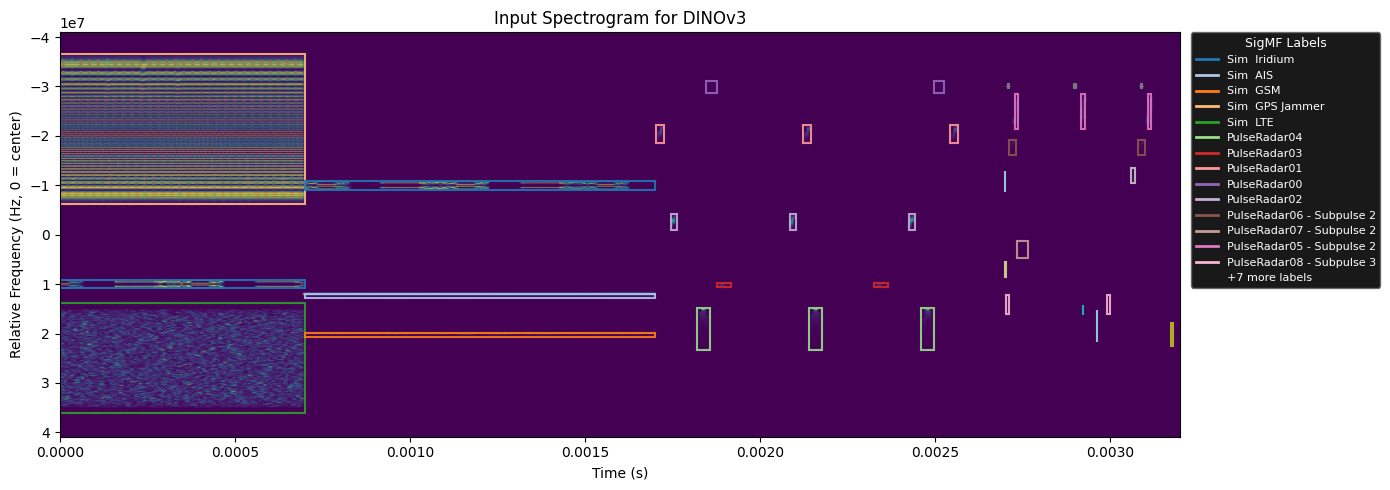

In [6]:
sigmf_path = Path(SIGMF_META_PATH)
if not sigmf_path.exists():
    candidates = sorted(Path('/home/sat3737/holoscan_demo_workspace').rglob('*.sigmf-meta'))
    if not candidates:
        raise FileNotFoundError('No .sigmf-meta files found in workspace')
    sigmf_path = candidates[0]
    print(f'Using first discovered SigMF file: {sigmf_path}')

usrp_chunk_s, usrp_shape = infer_usrp_chunk_duration_seconds(USRP_SPECTROGRAM_DIR)
chunk_seconds = DEFAULT_CHUNK_SECONDS
target_time_bins = None
shape_matched_chunk_s = None
if usrp_shape is not None:
    target_time_bins = int(max(usrp_shape))

if USE_USRP_SHAPE_MATCH and (target_time_bins is not None):
    # Match time-axis bin count to USRP image width while keeping FFT_SIZE fixed.
    _, probe_params = load_sigmf_samples(
        sigmf_path,
        start_s=SAMPLE_OFFSET_S,
        duration_s=0.01,
        capture_index=0,
        channel=0,
    )
    shape_matched_chunk_s = chunk_seconds_for_target_time_bins(
        sample_rate=probe_params['sample_rate'],
        target_time_bins=target_time_bins,
        nperseg=FFT_SIZE,
        noverlap=NOVERLAP,
    )
    if shape_matched_chunk_s is not None:
        chunk_seconds = shape_matched_chunk_s
elif USE_USRP_CHUNK_DURATION and (usrp_chunk_s is not None):
    chunk_seconds = usrp_chunk_s

iq, params = load_sigmf_samples(
    sigmf_path,
    start_s=SAMPLE_OFFSET_S,
    duration_s=chunk_seconds,
    capture_index=0,
    channel=0,
)

fs = params['sample_rate']
center_frequency = params['center_frequency']
f, t, sxx_db = generate_spectrogram(iq, fs=fs, nperseg=FFT_SIZE, noverlap=NOVERLAP, center_frequency=center_frequency)
spec_img, vmin, vmax = spectrogram_to_rgb(sxx_db)

ann_overlaps = get_overlapping_sigmf_annotations(
    meta_path=sigmf_path,
    window_start_s=SAMPLE_OFFSET_S,
    window_duration_s=chunk_seconds,
    capture_index=0,
 )

print(f'SigMF: {sigmf_path}')
print(f'Sample rate: {fs:.2f} Hz')
if usrp_shape is not None:
    print(f'USRP reference shape (rows, cols): {usrp_shape}')
if usrp_chunk_s is not None:
    print(f'USRP inferred chunk duration: {usrp_chunk_s:.3f} s')
if shape_matched_chunk_s is not None:
    print(f'Shape-matched chunk duration for {target_time_bins} time bins: {shape_matched_chunk_s:.6f} s')
print(f'Using chunk duration: {chunk_seconds:.3f} s')
print(f'Spectrogram shape: {sxx_db.shape}')
print(f'Overlapping SigMF annotations: {len(ann_overlaps)}')

freq_axis = f
if center_frequency is not None:
    freq_axis = f - float(center_frequency)

time_max_s = float(t[-1]) if len(t) > 0 else float(chunk_seconds)
freq_min_hz = float(np.min(freq_axis))
freq_max_hz = float(np.max(freq_axis))

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(
    spec_img,
    aspect='auto',
    origin='lower',
    extent=[0.0, time_max_s, freq_min_hz, freq_max_hz],
)
# Match the frequency direction used in the other plots.
ax.set_ylim(freq_max_hz, freq_min_hz)
ax.set_title('Input Spectrogram for DINOv3')
ax.set_xlabel('Time (s)')
if center_frequency is None:
    ax.set_ylabel('Frequency (Hz)')
else:
    ax.set_ylabel('Relative Frequency (Hz, 0 = center)')

if ann_overlaps:
    draw_sigmf_annotation_overlays(
        ax,
        ann_overlaps,
        time_max_s=time_max_s,
        freq_min_hz=freq_min_hz,
        freq_max_hz=freq_max_hz,
    )

plt.tight_layout()
plt.show()

In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

w = (spec_img.size[0] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
h = (spec_img.size[1] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
resized_img = spec_img.crop((0, 0, w, h))

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

img_tensor = transform(resized_img).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    feat = model.get_intermediate_layers(img_tensor, n=1, reshape=True, norm=True)[0]

features = feat.squeeze().view(feat.shape[1], -1).permute(1, 0).cpu().numpy()
grid_h = resized_img.size[1] // DINO_PATCH_SIZE
grid_w = resized_img.size[0] // DINO_PATCH_SIZE

print(f'Resized image: {resized_img.size}')
print(f'Patch grid: {grid_h} x {grid_w}')
print(f'Feature matrix: {features.shape}')

Resized image: (512, 1024)
Patch grid: 64 x 32
Feature matrix: (2048, 768)


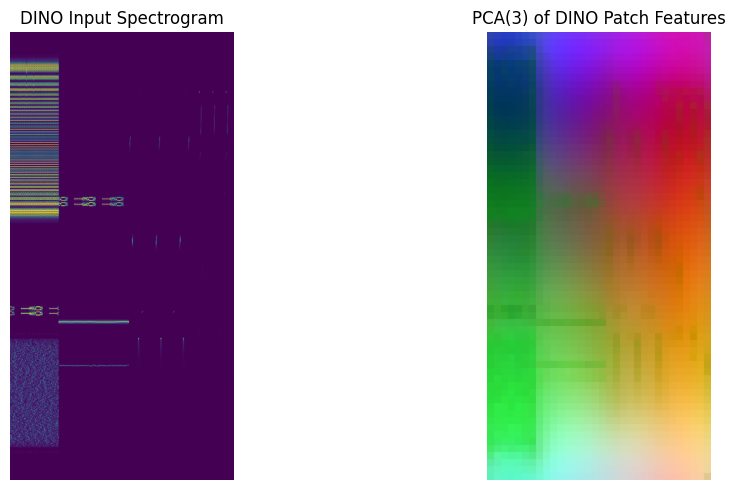

Explained variance ratio: [0.24483705 0.17893347 0.11416138]


In [10]:
pca = PCA(n_components=3, random_state=42)
pca_features = pca.fit_transform(features)

pmin = pca_features.min(axis=0, keepdims=True)
pmax = pca_features.max(axis=0, keepdims=True)
pca_scaled = (pca_features - pmin) / np.maximum(pmax - pmin, 1e-8)
pca_img = (255 * pca_scaled).astype(np.uint8).reshape(grid_h, grid_w, 3)
pca_up = Image.fromarray(pca_img).resize(resized_img.size, Image.NEAREST)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(resized_img)
plt.title('DINO Input Spectrogram')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pca_up)
plt.title('PCA(3) of DINO Patch Features')
plt.axis('off')

plt.tight_layout()
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_)

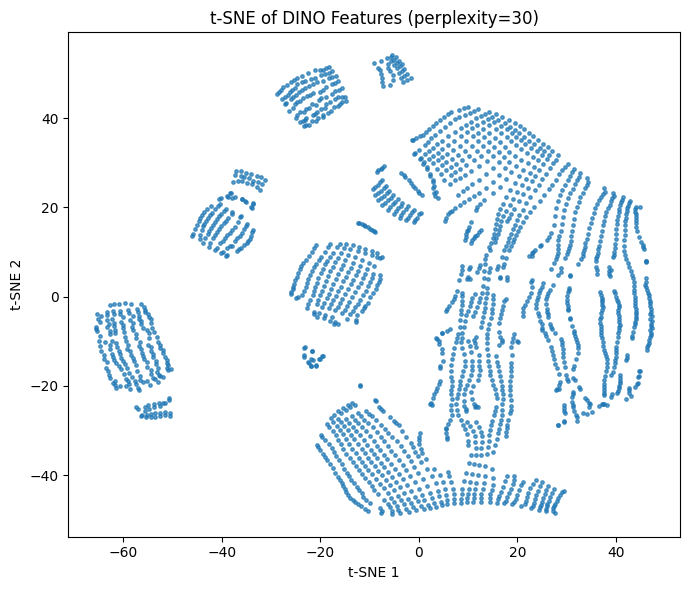

In [11]:
# t-SNE on DINO patch embeddings
perplexity = min(TSNE_PERPLEXITY, max(5, (features.shape[0] - 1) // 3))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate='auto',
    init='pca',
    random_state=TSNE_RANDOM_STATE,
)
emb_tsne = tsne.fit_transform(features)

plt.figure(figsize=(7, 6))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], s=6, alpha=0.7)
plt.title(f't-SNE of DINO Features (perplexity={perplexity})')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

Cluster counts: [ 866 1182]


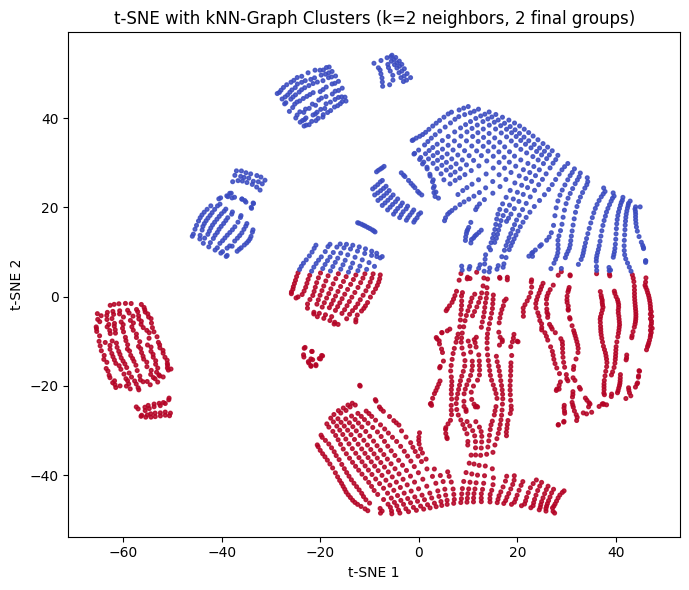

In [12]:
# kNN-graph clustering on t-SNE coordinates with k=2
def knn_graph_two_clusters(xy, k_neighbors=2, random_state=42):
    graph = kneighbors_graph(xy, n_neighbors=k_neighbors, mode='connectivity', include_self=False)
    graph = graph.maximum(graph.T)

    n_comp, comp_labels = connected_components(graph, directed=False)

    if n_comp == 1:
        # Fallback to force 2 clusters when graph is fully connected
        km = KMeans(n_clusters=2, random_state=random_state, n_init=20)
        return km.fit_predict(xy)

    counts = np.bincount(comp_labels)
    top2 = np.argsort(counts)[-2:]

    out = np.full(comp_labels.shape, -1, dtype=np.int32)
    out[comp_labels == top2[0]] = 0
    out[comp_labels == top2[1]] = 1

    missing = np.where(out < 0)[0]
    if len(missing) > 0:
        c0 = xy[out == 0].mean(axis=0)
        c1 = xy[out == 1].mean(axis=0)
        d0 = np.sum((xy[missing] - c0) ** 2, axis=1)
        d1 = np.sum((xy[missing] - c1) ** 2, axis=1)
        out[missing] = (d1 < d0).astype(np.int32)

    return out

cluster_labels = knn_graph_two_clusters(emb_tsne, k_neighbors=2, random_state=42)
cluster_map = cluster_labels.reshape(grid_h, grid_w)

print('Cluster counts:', np.bincount(cluster_labels))

plt.figure(figsize=(7, 6))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=cluster_labels, cmap='coolwarm', s=7, alpha=0.85)
plt.title('t-SNE with kNN-Graph Clusters (k=2 neighbors, 2 final groups)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

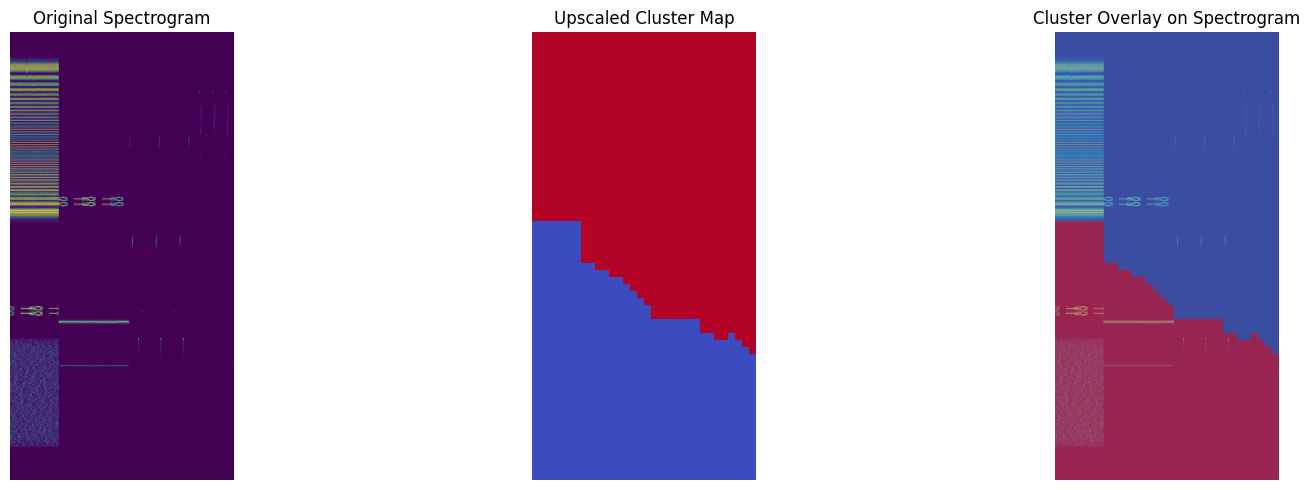

In [13]:
# Overlay cluster map on top of original spectrogram
cluster_img = Image.fromarray((cluster_map * 255).astype(np.uint8), mode='L').resize(resized_img.size, Image.NEAREST)
cluster_mask = np.array(cluster_img)
base = np.array(resized_img).astype(np.float32)

overlay = base.copy()
alpha = 0.45

cluster0 = cluster_mask < 128
cluster1 = ~cluster0

color0 = np.array([255, 80, 80], dtype=np.float32)
color1 = np.array([50, 170, 255], dtype=np.float32)

overlay[cluster0] = (1 - alpha) * overlay[cluster0] + alpha * color0
overlay[cluster1] = (1 - alpha) * overlay[cluster1] + alpha * color1
overlay = overlay.astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(resized_img)
ax[0].set_title('Original Spectrogram')
ax[0].axis('off')

ax[1].imshow(cluster_mask, cmap='coolwarm')
ax[1].set_title('Upscaled Cluster Map')
ax[1].axis('off')

ax[2].imshow(overlay)
ax[2].set_title('Cluster Overlay on Spectrogram')
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [16]:
def _axis_edges_from_centers(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if x.size == 0:
        return np.array([0.0, 1.0], dtype=np.float32)
    if x.size == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5], dtype=np.float32)

    mids = 0.5 * (x[:-1] + x[1:])
    first = x[0] - 0.5 * (x[1] - x[0])
    last = x[-1] + 0.5 * (x[-1] - x[-2])
    return np.concatenate(([first], mids, [last])).astype(np.float32)


def sigmf_annotation_pixel_mask(ann_list, time_axis_s, freq_axis_hz):
    time_axis_s = np.asarray(time_axis_s, dtype=np.float32).reshape(-1)
    freq_axis_hz = np.asarray(freq_axis_hz, dtype=np.float32).reshape(-1)
    mask = np.zeros((freq_axis_hz.size, time_axis_s.size), dtype=np.uint8)
    if not ann_list or time_axis_s.size == 0 or freq_axis_hz.size == 0:
        return mask

    t_edges = _axis_edges_from_centers(time_axis_s)
    f_edges = _axis_edges_from_centers(freq_axis_hz)

    for ann in ann_list:
        t0 = float(ann.get('t0', 0.0))
        t1 = float(ann.get('t1', 0.0))
        if t1 < t0:
            t0, t1 = t1, t0
        if t1 <= t_edges[0] or t0 >= t_edges[-1]:
            continue

        t_sel = np.logical_and(t_edges[:-1] < t1, t_edges[1:] > t0)
        if not np.any(t_sel):
            continue

        f0 = ann.get('f0', None)
        f1 = ann.get('f1', None)
        if f0 is None or f1 is None:
            f_sel = np.ones(freq_axis_hz.shape, dtype=bool)
        else:
            f0 = float(f0)
            f1 = float(f1)
            if f1 < f0:
                f0, f1 = f1, f0
            if f1 <= f_edges[0] or f0 >= f_edges[-1]:
                continue
            f_sel = np.logical_and(f_edges[:-1] < f1, f_edges[1:] > f0)

        if np.any(f_sel):
            mask[np.ix_(f_sel, t_sel)] = 1

    return mask


def resize_binary_mask_to_patch_grid(mask_px, patch_h, patch_w, min_coverage=0.10):
    mask_px = np.asarray(mask_px, dtype=np.float32)
    h, w = mask_px.shape
    row_edges = np.linspace(0, h, int(patch_h) + 1).astype(int)
    col_edges = np.linspace(0, w, int(patch_w) + 1).astype(int)
    mask_patch = np.zeros((int(patch_h), int(patch_w)), dtype=np.uint8)

    for i in range(int(patch_h)):
        r0, r1 = row_edges[i], row_edges[i + 1]
        if r1 <= r0:
            r1 = min(h, r0 + 1)
        for j in range(int(patch_w)):
            c0, c1 = col_edges[j], col_edges[j + 1]
            if c1 <= c0:
                c1 = min(w, c0 + 1)
            patch = mask_px[r0:r1, c0:c1]
            if patch.size == 0:
                continue
            mask_patch[i, j] = np.uint8(np.mean(patch) >= float(min_coverage))

    return mask_patch


def sigmf_annotation_patch_mask(ann_list, time_axis_s, freq_axis_hz, patch_h, patch_w, min_coverage=0.10):
    mask_px = sigmf_annotation_pixel_mask(ann_list, time_axis_s, freq_axis_hz)
    mask_patch = resize_binary_mask_to_patch_grid(
        mask_px,
        patch_h=patch_h,
        patch_w=patch_w,
        min_coverage=min_coverage,
    )
    return mask_patch.astype(np.uint8), mask_px.astype(np.uint8)


def binary_mask_metrics(pred_mask, gt_mask):
    pred = np.asarray(pred_mask, dtype=bool)
    gt = np.asarray(gt_mask, dtype=bool)
    if pred.shape != gt.shape:
        raise ValueError(f'Mask shape mismatch: pred={pred.shape}, gt={gt.shape}')

    tp = float(np.logical_and(pred, gt).sum())
    fp = float(np.logical_and(pred, np.logical_not(gt)).sum())
    fn = float(np.logical_and(np.logical_not(pred), gt).sum())
    tn = float(np.logical_and(np.logical_not(pred), np.logical_not(gt)).sum())

    precision = tp / max(tp + fp, 1.0)
    recall = tp / max(tp + fn, 1.0)
    iou = tp / max(tp + fp + fn, 1.0)
    f1 = 0.0 if (precision + recall) <= 0 else (2.0 * precision * recall / (precision + recall))
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1.0)

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision': precision,
        'recall': recall,
        'iou': iou,
        'f1': f1,
        'accuracy': accuracy,
        'gt_foreground_fraction': float(gt.mean()),
    }

In [22]:
def _annotation_projection_freq_axis(freq_axis_hz, ann_list):
    freq_axis_hz = np.asarray(freq_axis_hz, dtype=np.float32).reshape(-1)
    if freq_axis_hz.size == 0 or not ann_list:
        return freq_axis_hz

    ann_freqs = []
    for ann in ann_list:
        for key in ('f0', 'f1'):
            value = ann.get(key, None)
            if value is not None:
                ann_freqs.append(abs(float(value)))

    if not ann_freqs:
        return freq_axis_hz

    axis_min = float(np.min(freq_axis_hz))
    axis_max = float(np.max(freq_axis_hz))
    axis_span = max(axis_max - axis_min, 1.0)
    axis_center = 0.5 * (axis_min + axis_max)
    ann_scale = float(np.percentile(np.asarray(ann_freqs, dtype=np.float32), 95.0))

    if abs(axis_center) > max(10.0 * axis_span, 10.0 * ann_scale) and ann_scale < (2.0 * axis_span):
        return (freq_axis_hz - axis_center).astype(np.float32)

    return freq_axis_hz


def sigmf_annotation_pixel_mask(ann_list, time_axis_s, freq_axis_hz):
    time_axis_s = np.asarray(time_axis_s, dtype=np.float32).reshape(-1)
    freq_axis_hz = _annotation_projection_freq_axis(freq_axis_hz, ann_list)
    mask = np.zeros((freq_axis_hz.size, time_axis_s.size), dtype=np.uint8)
    if not ann_list or time_axis_s.size == 0 or freq_axis_hz.size == 0:
        return mask

    t_edges = _axis_edges_from_centers(time_axis_s)
    f_edges = _axis_edges_from_centers(freq_axis_hz)

    for ann in ann_list:
        t0 = float(ann.get('t0', 0.0))
        t1 = float(ann.get('t1', 0.0))
        if t1 < t0:
            t0, t1 = t1, t0
        if t1 <= t_edges[0] or t0 >= t_edges[-1]:
            continue

        t_sel = np.logical_and(t_edges[:-1] < t1, t_edges[1:] > t0)
        if not np.any(t_sel):
            continue

        f0 = ann.get('f0', None)
        f1 = ann.get('f1', None)
        if f0 is None or f1 is None:
            f_sel = np.ones(freq_axis_hz.shape, dtype=bool)
        else:
            f0 = float(f0)
            f1 = float(f1)
            if f1 < f0:
                f0, f1 = f1, f0
            if f1 <= f_edges[0] or f0 >= f_edges[-1]:
                continue
            f_sel = np.logical_and(f_edges[:-1] < f1, f_edges[1:] > f0)

        if np.any(f_sel):
            mask[np.ix_(f_sel, t_sel)] = 1

    return mask

## Comparative Experiments: Ideas 1, 3, and 4

This section compares:
1. **Idea 1**: Grayscale + fixed dB scaling before DINO.
2. **Idea 3**: Cluster in embedding/PCA space (use t-SNE only for visualization).
3. **Idea 4**: Apply a local smoothness prior to the clustered patch map.

The cells below compute each variant, then compare overlays and simple quality metrics.

In [30]:
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from PIL import Image
from scipy import ndimage
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# ---- Helpers ----
def _prep_dino_image(img_rgb):
    w = (img_rgb.size[0] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
    h = (img_rgb.size[1] // DINO_PATCH_SIZE) * DINO_PATCH_SIZE
    return img_rgb.crop((0, 0, w, h))


def _extract_dino_features_from_rgb(img_rgb):
    img_rgb = _prep_dino_image(img_rgb)
    transform_local = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    x = transform_local(img_rgb).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat_local = model.get_intermediate_layers(x, n=1, reshape=True, norm=True)[0]
    feat_local = feat_local.squeeze().view(feat_local.shape[1], -1).permute(1, 0).cpu().numpy()
    gh = img_rgb.size[1] // DINO_PATCH_SIZE
    gw = img_rgb.size[0] // DINO_PATCH_SIZE
    return feat_local, gh, gw, img_rgb


def _db_to_fixed_grayscale_rgb(sxx_db_local, db_min=-110.0, db_max=-40.0):
    x = np.clip((np.asarray(sxx_db_local, dtype=np.float32) - db_min) / max(db_max - db_min, 1e-8), 0.0, 1.0)
    gray = (255.0 * x).astype(np.uint8)
    rgb = np.stack([gray, gray, gray], axis=-1)
    return Image.fromarray(rgb)


def _normalize_map01_local(x, low_q=5.0, high_q=95.0):
    x = np.asarray(x, dtype=np.float32)
    vals = x[np.isfinite(x)]
    if vals.size == 0:
        return np.zeros_like(x, dtype=np.float32)
    lo = float(np.percentile(vals, low_q))
    hi = float(np.percentile(vals, high_q))
    if hi <= lo:
        hi = lo + 1e-6
    out = (x - lo) / (hi - lo)
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def _normalize_vector01(x):
    x = np.asarray(x, dtype=np.float32)
    if x.size == 0:
        return x.astype(np.float32)
    lo = float(np.min(x))
    hi = float(np.max(x))
    if hi <= lo + 1e-8:
        return np.ones_like(x, dtype=np.float32)
    return ((x - lo) / (hi - lo)).astype(np.float32)


def patch_mean_map(x_px, patch_h, patch_w):
    x_px = np.asarray(x_px, dtype=np.float32)
    bh = max(1, x_px.shape[0] // patch_h)
    bw = max(1, x_px.shape[1] // patch_w)
    h_use = patch_h * bh
    w_use = patch_w * bw
    x_crop = x_px[:h_use, :w_use]
    return x_crop.reshape(patch_h, bh, patch_w, bw).mean(axis=(1, 3)).astype(np.float32)


def dino_seed_patch_map(sxx_db_local, patch_h, patch_w):
    x_db = np.asarray(sxx_db_local, dtype=np.float32)
    p_lin = np.power(10.0, x_db / 10.0)
    p_floor = max(float(np.percentile(p_lin, 30.0)), 1e-20)
    rel_db = 10.0 * np.log10(np.maximum(p_lin, 1e-20) / p_floor)
    rel_db = np.clip(rel_db, -10.0, 25.0)

    persistence_px = ndimage.uniform_filter(rel_db, size=(1, 7), mode='nearest')
    local_contrast_px = rel_db - ndimage.uniform_filter(rel_db, size=(5, 5), mode='nearest')

    persistence_n = _normalize_map01_local(persistence_px)
    contrast_n = _normalize_map01_local(local_contrast_px)
    seed_px = (0.65 * persistence_n + 0.35 * contrast_n).astype(np.float32)
    return patch_mean_map(seed_px, patch_h, patch_w)


def _feature_affinity_matrix(x_embed, k=8):
    x_embed = np.asarray(x_embed, dtype=np.float32)
    n = x_embed.shape[0]
    nn = NearestNeighbors(n_neighbors=min(int(k) + 1, n), metric='cosine')
    nn.fit(x_embed)
    dist, idx = nn.kneighbors(x_embed)

    valid = dist[:, 1:]
    sigma = float(np.median(valid[valid > 0])) if np.any(valid > 0) else 1.0
    sigma = max(sigma, 1e-3)

    aff = np.zeros((n, n), dtype=np.float32)
    for row in range(n):
        for col, d in zip(idx[row, 1:], dist[row, 1:]):
            w = float(np.exp(-(d ** 2) / (2.0 * sigma ** 2)))
            aff[row, col] = max(aff[row, col], w)
            aff[col, row] = max(aff[col, row], w)

    np.fill_diagonal(aff, 1.0)
    return aff


def _add_spatial_affinity(aff, x_embed, patch_h, patch_w, spatial_weight=0.35):
    out = np.asarray(aff, dtype=np.float32).copy()
    for r in range(patch_h):
        for c in range(patch_w):
            idx0 = r * patch_w + c
            for dr, dc in ((1, 0), (0, 1)):
                rr = r + dr
                cc = c + dc
                if rr >= patch_h or cc >= patch_w:
                    continue
                idx1 = rr * patch_w + cc
                sim = float(np.dot(x_embed[idx0], x_embed[idx1]))
                sim = float(np.clip(0.5 * (sim + 1.0), 0.0, 1.0))
                w = float(spatial_weight * sim)
                out[idx0, idx1] = max(out[idx0, idx1], w)
                out[idx1, idx0] = max(out[idx1, idx0], w)
    np.fill_diagonal(out, 1.0)
    return out


def _smooth_binary_label_map(label_map, iters=2, min_component_size=6):
    out = label_map.copy().astype(np.uint8)

    for _ in range(int(iters)):
        avg = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
        out = (avg >= 0.5).astype(np.uint8)

    comp, n_comp = ndimage.label(out)
    if n_comp > 0:
        sizes = ndimage.sum(out, comp, index=np.arange(1, n_comp + 1))
        small_ids = np.where(sizes < int(min_component_size))[0] + 1
        if len(small_ids) > 0:
            small_mask = np.isin(comp, small_ids)
            neigh = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
            out[small_mask] = (neigh[small_mask] >= 0.5).astype(np.uint8)

    comp_bg, n_bg = ndimage.label(out == 0)
    if n_bg > 0:
        sizes_bg = ndimage.sum(out == 0, comp_bg, index=np.arange(1, n_bg + 1))
        small_bg = np.where(sizes_bg < int(min_component_size))[0] + 1
        if len(small_bg) > 0:
            small_mask_bg = np.isin(comp_bg, small_bg)
            neigh = ndimage.uniform_filter(out.astype(np.float32), size=3, mode='nearest')
            out[small_mask_bg] = (neigh[small_mask_bg] >= 0.5).astype(np.uint8)

    return out


def _overlay_from_mask(base_img_rgb, mask_patch, alpha=0.45):
    up = Image.fromarray((mask_patch * 255).astype(np.uint8), mode='L').resize(base_img_rgb.size, Image.NEAREST)
    mask = np.array(up) >= 128
    base = np.array(base_img_rgb).astype(np.float32)
    over = base.copy()
    color_fg = np.array([60, 175, 255], dtype=np.float32)
    color_bg = np.array([255, 90, 90], dtype=np.float32)
    over[~mask] = (1 - alpha) * over[~mask] + alpha * color_bg
    over[mask] = (1 - alpha) * over[mask] + alpha * color_fg
    return over.astype(np.uint8)


def _spatial_metrics(mask_patch):
    v_dis = np.mean(mask_patch[1:, :] != mask_patch[:-1, :])
    h_dis = np.mean(mask_patch[:, 1:] != mask_patch[:, :-1])
    edge_disagreement = 0.5 * (v_dis + h_dis)
    comp_fg, n_fg = ndimage.label(mask_patch == 1)
    comp_bg, n_bg = ndimage.label(mask_patch == 0)
    return {
        'smoothness': float(1.0 - edge_disagreement),
        'edge_disagreement': float(edge_disagreement),
        'num_components_total': int(n_fg + n_bg),
        'foreground_fraction': float(mask_patch.mean()),
    }


def _normalized_patch_coords(patch_h, patch_w):
    row = np.linspace(-1.0, 1.0, patch_h, dtype=np.float32)
    col = np.linspace(-1.0, 1.0, patch_w, dtype=np.float32)
    return np.meshgrid(row, col, indexing='ij')


def _remove_positional_trend(x_embed, patch_h, patch_w, ridge=1e-3):
    x_embed = np.asarray(x_embed, dtype=np.float32)
    row_grid, col_grid = _normalized_patch_coords(patch_h, patch_w)
    design = np.stack([
        np.ones(row_grid.size, dtype=np.float32),
        row_grid.reshape(-1),
        col_grid.reshape(-1),
        (row_grid ** 2).reshape(-1),
        (col_grid ** 2).reshape(-1),
        (row_grid * col_grid).reshape(-1),
    ], axis=1)
    xtx = design.T @ design
    beta = np.linalg.solve(xtx + ridge * np.eye(design.shape[1], dtype=np.float32), design.T @ x_embed)
    trend = design @ beta
    detrended = (x_embed - trend).astype(np.float32)
    trend_energy_ratio = float(np.linalg.norm(trend) / max(np.linalg.norm(x_embed), 1e-6))
    return detrended, {
        'trend_energy_ratio': trend_energy_ratio,
        'row_grid': row_grid,
        'col_grid': col_grid,
    }


def _auto_cluster_count(patch_h, patch_w, min_clusters=3, max_clusters=6):
    n = int(patch_h * patch_w)
    if n <= 4:
        return 2
    auto = int(np.round(np.sqrt(float(n)) / 4.0))
    auto = int(np.clip(auto, min_clusters, max_clusters))
    return int(np.clip(auto, 2, max(2, n - 1)))


def _graph_local_coherence_map(aff, label_map, patch_h, patch_w, top_k=6):
    labels = label_map.reshape(-1)
    n = labels.size
    graph_same = np.zeros(n, dtype=np.float32)
    graph_diff = np.zeros(n, dtype=np.float32)
    spatial_same = np.zeros(n, dtype=np.float32)
    spatial_diff = np.zeros(n, dtype=np.float32)

    for idx0 in range(n):
        same_mask = labels == labels[idx0]
        same_mask[idx0] = False
        diff_mask = ~same_mask
        diff_mask[idx0] = False

        same_vals = aff[idx0, same_mask]
        diff_vals = aff[idx0, diff_mask]
        if same_vals.size > 0:
            graph_same[idx0] = float(np.mean(np.sort(same_vals)[-min(int(top_k), same_vals.size):]))
        if diff_vals.size > 0:
            graph_diff[idx0] = float(np.mean(np.sort(diff_vals)[-min(int(top_k), diff_vals.size):]))

    for r in range(patch_h):
        for c in range(patch_w):
            idx0 = r * patch_w + c
            same_vals = []
            diff_vals = []
            for rr in range(max(0, r - 1), min(patch_h, r + 2)):
                for cc in range(max(0, c - 1), min(patch_w, c + 2)):
                    if rr == r and cc == c:
                        continue
                    idx1 = rr * patch_w + cc
                    if labels[idx1] == labels[idx0]:
                        same_vals.append(float(aff[idx0, idx1]))
                    else:
                        diff_vals.append(float(aff[idx0, idx1]))
            if same_vals:
                spatial_same[idx0] = float(np.mean(same_vals))
            if diff_vals:
                spatial_diff[idx0] = float(np.mean(diff_vals))

    coherence = (
        0.40 * graph_same
        + 0.35 * spatial_same
        - 0.15 * graph_diff
        - 0.10 * spatial_diff
    )
    return _normalize_map01_local(coherence.reshape(patch_h, patch_w))


def _cluster_summary_table(aff, label_map, seed_norm, coherence_map):
    labels = label_map.reshape(-1)
    seed_flat = seed_norm.reshape(-1)
    coherence_flat = coherence_map.reshape(-1)
    rows = []
    for cls in np.unique(labels):
        cls_mask = labels == cls
        not_cls = ~cls_mask
        cls_map = (label_map == cls).astype(np.uint8)
        internal_aff = float(aff[np.ix_(cls_mask, cls_mask)].mean()) if int(cls_mask.sum()) > 1 else 0.0
        boundary_aff = float(aff[np.ix_(cls_mask, not_cls)].mean()) if np.any(not_cls) else 0.0
        rows.append({
            'cluster': int(cls),
            'size_fraction': float(cls_mask.mean()),
            'seed_mean': float(seed_flat[cls_mask].mean()) if np.any(cls_mask) else 0.0,
            'coherence_mean': float(coherence_flat[cls_mask].mean()) if np.any(cls_mask) else 0.0,
            'internal_aff': internal_aff,
            'boundary_aff': boundary_aff,
            'smoothness': _spatial_metrics(cls_map)['smoothness'],
        })

    if not rows:
        return []

    seed_vals = np.array([row['seed_mean'] for row in rows], dtype=np.float32)
    coh_vals = np.array([row['coherence_mean'] for row in rows], dtype=np.float32)
    int_vals = np.array([row['internal_aff'] for row in rows], dtype=np.float32)
    bnd_vals = np.array([row['boundary_aff'] for row in rows], dtype=np.float32)
    smooth_vals = np.array([row['smoothness'] for row in rows], dtype=np.float32)
    size_vals = np.array([row['size_fraction'] for row in rows], dtype=np.float32)

    seed_n = _normalize_vector01(seed_vals)
    coh_n = _normalize_vector01(coh_vals)
    int_n = _normalize_vector01(int_vals)
    bnd_n = _normalize_vector01(bnd_vals)
    smooth_n = _normalize_vector01(smooth_vals)
    size_penalty = np.clip((size_vals - 0.45) / 0.35, 0.0, 1.0).astype(np.float32)

    for idx, row in enumerate(rows):
        combined = (
            0.35 * seed_n[idx]
            + 0.30 * coh_n[idx]
            + 0.20 * int_n[idx]
            + 0.15 * smooth_n[idx]
            - 0.20 * bnd_n[idx]
            - 0.10 * size_penalty[idx]
        )
        row['combined_score'] = float(combined)
        row['size_penalty'] = float(size_penalty[idx])

    rows.sort(key=lambda x: x['combined_score'], reverse=True)
    return rows


def _select_signal_clusters(cluster_rows, max_clusters=3):
    if not cluster_rows:
        return []

    best_score = float(cluster_rows[0]['combined_score'])
    score_floor = max(0.30, 0.75 * best_score)
    selected = []
    for row in cluster_rows:
        if row['combined_score'] < score_floor:
            continue
        if row['size_fraction'] > 0.60 and row['combined_score'] < 0.95 * best_score:
            continue
        selected.append(int(row['cluster']))
        if len(selected) >= int(max_clusters):
            break

    if not selected:
        selected = [int(cluster_rows[0]['cluster'])]
    return selected


def dino_region_grouping_mask(
    features_local,
    patch_h,
    patch_w,
    seed_patch=None,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=None,
    random_state=42,
):
    x = np.asarray(features_local, dtype=np.float32)
    d = min(12, x.shape[1], x.shape[0] - 1)
    if d >= 1:
        x = PCA(n_components=d, random_state=random_state).fit_transform(x)

    x_detrended, pos_info = _remove_positional_trend(x, patch_h, patch_w)
    x_detrended = x_detrended - x_detrended.mean(axis=0, keepdims=True)
    x_detrended = x_detrended / np.maximum(np.linalg.norm(x_detrended, axis=1, keepdims=True), 1e-6)

    aff = _feature_affinity_matrix(x_detrended, k=feature_knn)
    aff = _add_spatial_affinity(aff, x_detrended, patch_h, patch_w, spatial_weight=spatial_weight)

    if n_clusters is None:
        n_clusters = _auto_cluster_count(patch_h, patch_w)
    n_clusters = int(np.clip(n_clusters, 2, max(2, x_detrended.shape[0] - 1)))

    clustering = SpectralClustering(
        n_clusters=n_clusters,
        affinity='precomputed',
        assign_labels='kmeans',
        random_state=random_state,
    )
    cluster_map = clustering.fit_predict(aff).reshape(patch_h, patch_w)

    if seed_patch is None:
        seed_patch = np.zeros((patch_h, patch_w), dtype=np.float32)
    seed_patch = np.asarray(seed_patch, dtype=np.float32)
    seed_norm = _normalize_map01_local(seed_patch)

    coherence_map = _graph_local_coherence_map(aff, cluster_map, patch_h, patch_w)
    cluster_rows = _cluster_summary_table(aff, cluster_map, seed_norm, coherence_map)
    selected_clusters = _select_signal_clusters(cluster_rows)

    selected_label_map = np.isin(cluster_map, selected_clusters).astype(np.uint8)
    selected_label_map = _smooth_binary_label_map(
        selected_label_map,
        iters=smooth_iters,
        min_component_size=min_component_size,
    )

    if float(selected_label_map.mean()) <= 0.0:
        selected_label_map = np.isin(cluster_map, selected_clusters).astype(np.uint8)

    cluster_quality = np.zeros((patch_h, patch_w), dtype=np.float32)
    cluster_scores = {int(row['cluster']): float(row['combined_score']) for row in cluster_rows}
    if cluster_rows:
        score_vals = np.array([max(0.0, row['combined_score']) for row in cluster_rows], dtype=np.float32)
        score_vals = _normalize_vector01(score_vals)
        for row, score_val in zip(cluster_rows, score_vals):
            cluster_quality[cluster_map == int(row['cluster'])] = float(score_val)

    selected_soft = ndimage.uniform_filter(selected_label_map.astype(np.float32), size=3, mode='nearest')
    selected_soft = np.clip(selected_soft, 0.0, 1.0).astype(np.float32)

    score_map = (
        0.60 * coherence_map
        + 0.25 * cluster_quality
        + 0.15 * seed_norm
    ).astype(np.float32)
    score_map = (score_map * (0.20 + 0.80 * selected_soft)).astype(np.float32)
    score_map = ndimage.uniform_filter(score_map, size=3, mode='nearest').astype(np.float32)

    candidate = selected_soft >= 0.20
    candidate_scores = score_map[candidate]
    score_q = float(np.clip(score_q, 0.50, 0.95))
    if candidate_scores.size >= 4:
        thr = float(np.quantile(candidate_scores, score_q))
        mask = np.logical_and(candidate, score_map >= thr).astype(np.uint8)
        if float(mask.mean()) < 0.02:
            mask = (selected_soft >= 0.35).astype(np.uint8)
            thr = float(np.quantile(score_map[mask.astype(bool)], min(score_q, 0.80)))
    else:
        thr = float(np.quantile(score_map, score_q))
        mask = (score_map >= thr).astype(np.uint8)

    mask = _smooth_binary_label_map(mask, iters=1, min_component_size=max(2, min_component_size // 2))

    return {
        'mask': mask.astype(np.uint8),
        'score': score_map.astype(np.float32),
        'label_map': selected_label_map.astype(np.uint8),
        'cluster_map': cluster_map.astype(np.int32),
        'coherence_map': coherence_map.astype(np.float32),
        'cluster_quality_map': cluster_quality.astype(np.float32),
        'selected_support_map': selected_soft.astype(np.float32),
        'threshold': float(thr),
        'cluster_scores': cluster_scores,
        'cluster_table': cluster_rows,
        'selected_clusters': [int(v) for v in selected_clusters],
        'n_clusters': int(n_clusters),
        'positional_trend_ratio': float(pos_info['trend_energy_ratio']),
    }


def dino_grouping_from_spectrogram(
    sxx_db_local,
    db_min=-110.0,
    db_max=-40.0,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    use_seed=True,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=None,
    random_state=42,
):
    img_rgb = _db_to_fixed_grayscale_rgb(sxx_db_local, db_min=db_min, db_max=db_max)
    feat_local, gh, gw, img_rgb = _extract_dino_features_from_rgb(img_rgb)
    seed_patch = dino_seed_patch_map(sxx_db_local, gh, gw) if use_seed else np.zeros((gh, gw), dtype=np.float32)
    grouped = dino_region_grouping_mask(
        feat_local,
        patch_h=gh,
        patch_w=gw,
        seed_patch=seed_patch,
        feature_knn=feature_knn,
        spatial_weight=spatial_weight,
        score_q=score_q,
        smooth_iters=smooth_iters,
        min_component_size=min_component_size,
        n_clusters=n_clusters,
        random_state=random_state,
    )
    grouped.update({
        'input_img': img_rgb,
        'seed_patch': seed_patch.astype(np.float32),
        'features': feat_local,
        'shape': (gh, gw),
    })
    return grouped


# ---- Compare old-style RGB input vs the revised grouping pipeline ----
feat_rgb, gh_rgb, gw_rgb, img_rgb = _extract_dino_features_from_rgb(resized_img)
seed_rgb = dino_seed_patch_map(sxx_db, gh_rgb, gw_rgb)
run_rgb = dino_region_grouping_mask(
    feat_rgb,
    patch_h=gh_rgb,
    patch_w=gw_rgb,
    seed_patch=seed_rgb,
    feature_knn=8,
    spatial_weight=0.20,
    score_q=0.60,
    smooth_iters=1,
    min_component_size=4,
    n_clusters=4,
    random_state=42,
)
run_rgb.update({'input_img': img_rgb, 'seed_patch': seed_rgb})

run_gray_noseed = dino_grouping_from_spectrogram(
    sxx_db,
    db_min=-110.0,
    db_max=-40.0,
    feature_knn=8,
    spatial_weight=0.20,
    score_q=0.60,
    use_seed=False,
    smooth_iters=1,
    min_component_size=4,
    n_clusters=4,
    random_state=42,
)

run_gray_seeded = dino_grouping_from_spectrogram(
    sxx_db,
    db_min=-110.0,
    db_max=-40.0,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    use_seed=True,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=4,
    random_state=42,
)

run_gray_seeded_strong = dino_grouping_from_spectrogram(
    sxx_db,
    db_min=-110.0,
    db_max=-40.0,
    feature_knn=8,
    spatial_weight=0.50,
    score_q=0.55,
    use_seed=True,
    smooth_iters=2,
    min_component_size=6,
    n_clusters=5,
    random_state=42,
)


dino_group_runs = {
    'rgb_input_grouping': run_rgb,
    'gray_grouping_no_seed': run_gray_noseed,
    'gray_grouping_seeded': run_gray_seeded,
    'gray_grouping_seeded_stronger_spatial': run_gray_seeded_strong,
}

dino_group_overlays = {
    name: _overlay_from_mask(run['input_img'], run['mask'])
    for name, run in dino_group_runs.items()
}

metric_rows = []
for name, run in dino_group_runs.items():
    row = _spatial_metrics(run['mask'])
    row['method'] = name
    row['threshold'] = float(run['threshold'])
    row['mean_score'] = float(np.mean(run['score']))
    row['mean_local_coherence'] = float(np.mean(run['coherence_map']))
    row['seed_mean'] = float(np.mean(run['seed_patch']))
    row['selected_clusters'] = int(len(run['selected_clusters']))
    row['n_clusters'] = int(run['n_clusters'])
    row['positional_trend_ratio'] = float(run['positional_trend_ratio'])
    metric_rows.append(row)

comparison_df = pd.DataFrame(metric_rows).set_index('method').sort_values(
    ['smoothness', 'foreground_fraction'],
    ascending=[False, True],
)
print('DINO grouping comparison metrics:')
display(comparison_df)

DINO grouping comparison metrics:


,smoothness,edge_disagreement,num_components_total,foreground_fraction,threshold,mean_score,mean_local_coherence,seed_mean,selected_clusters,n_clusters,positional_trend_ratio
method,,,,,,,,,,,
rgb_input_grouping,0.991235,0.008765,3,0.033203,0.724614,0.112907,0.533256,0.342221,1,4,0.843607
gray_grouping_no_seed,0.972358,0.027642,3,0.162598,0.568704,0.236034,0.576235,0.000000,2,4,0.898695
gray_grouping_seeded,0.969374,0.030626,3,0.173828,0.650787,0.276188,0.571384,0.342221,2,4,0.898695
gray_grouping_seeded_stronger_spatial,0.962586,0.037414,3,0.131836,0.743148,0.249954,0.563199,0.342221,1,5,0.898695


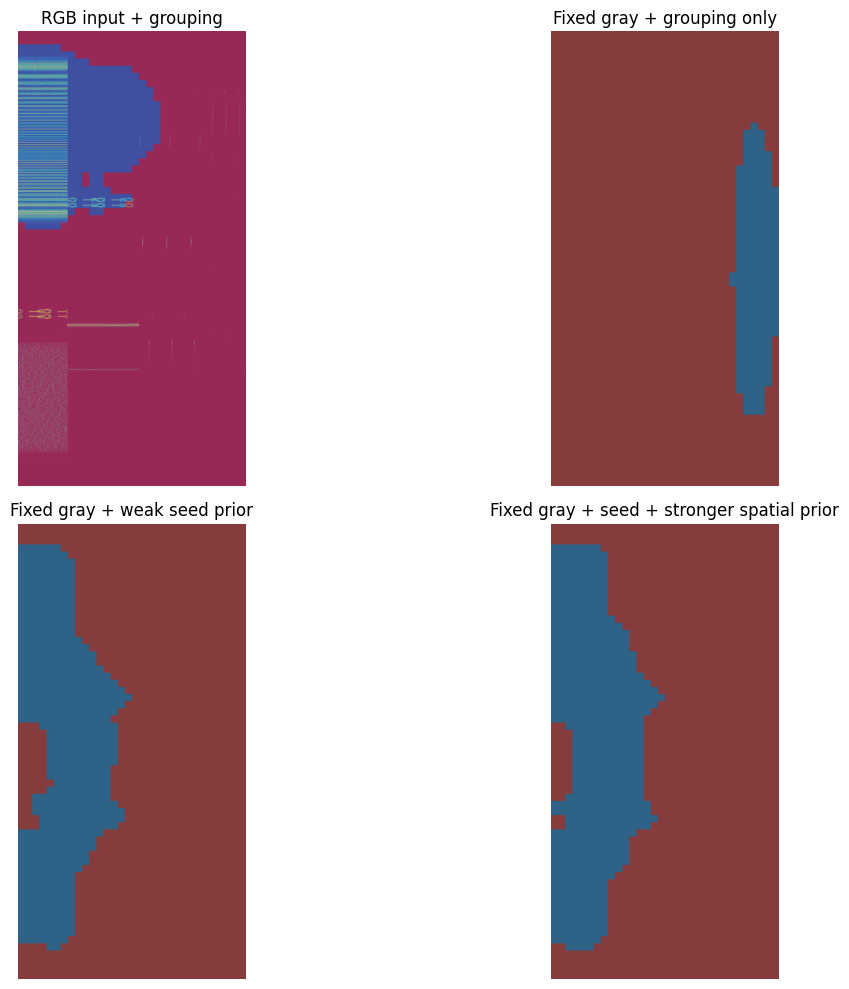

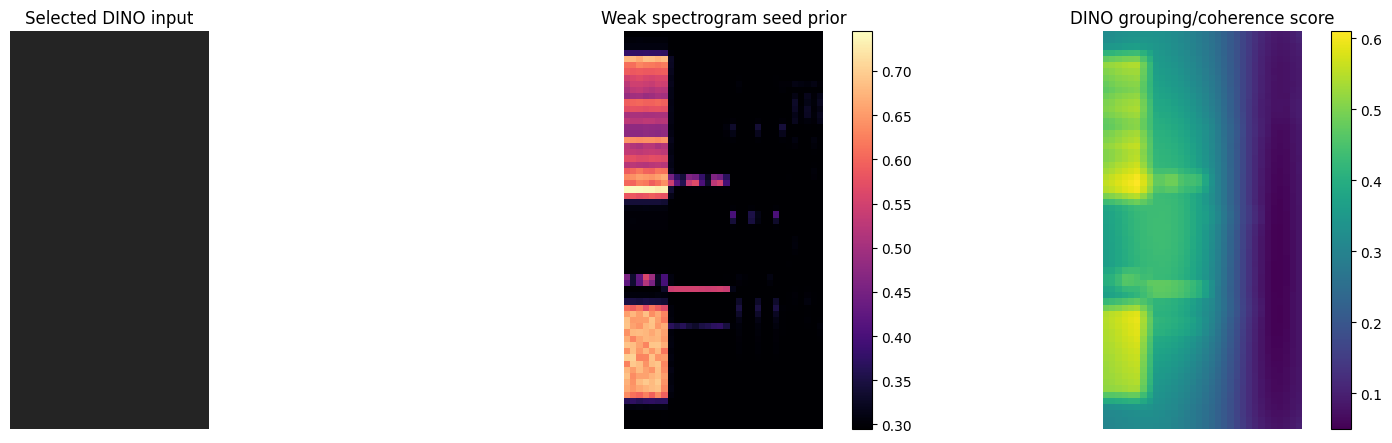

In [9]:
# Visual comparison of the revised DINO grouping variants
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
plot_order = [
    ('rgb_input_grouping', 'RGB input + grouping'),
    ('gray_grouping_no_seed', 'Fixed gray + grouping only'),
    ('gray_grouping_seeded', 'Fixed gray + weak seed prior'),
    ('gray_grouping_seeded_stronger_spatial', 'Fixed gray + seed + stronger spatial prior'),
]

for axes, (key, title) in zip(ax.reshape(-1), plot_order):
    axes.imshow(dino_group_overlays[key])
    axes.set_title(title)
    axes.axis('off')

plt.tight_layout()
plt.show()

selected = dino_group_runs['gray_grouping_seeded']
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].imshow(selected['input_img'])
ax[0].set_title('Selected DINO input')
ax[0].axis('off')

im1 = ax[1].imshow(selected['seed_patch'], cmap='magma')
ax[1].set_title('Weak spectrogram seed prior')
ax[1].axis('off')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(selected['score'], cmap='viridis')
ax[2].set_title('DINO grouping/coherence score')
ax[2].axis('off')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

plt.tight_layout()
plt.show()

SigMF annotations overlapping current window: 36
DINO grouping comparison metrics vs SigMF annotation boxes:


,smoothness,edge_disagreement,num_components_total,foreground_fraction,tp,fp,fn,tn,precision,recall,iou,f1,accuracy,gt_foreground_fraction,threshold,mean_score,seed_mean
method,,,,,,,,,,,,,,,,,
gray_grouping_seeded,0.969202,0.030798,3,0.270020,322.0,231.0,108.0,1387.0,0.582278,0.748837,0.487141,0.655137,0.834473,0.209961,0.407774,0.287491,0.342221
gray_grouping_seeded_stronger_spatial,0.970698,0.029302,4,0.284180,331.0,251.0,99.0,1367.0,0.568729,0.769767,0.486050,0.654150,0.829102,0.209961,0.402166,0.286492,0.342221
rgb_input_grouping,0.979283,0.020717,3,0.190918,196.0,195.0,234.0,1423.0,0.501279,0.455814,0.313600,0.477467,0.790527,0.209961,0.400836,0.278012,0.342221
gray_grouping_no_seed,0.981155,0.018845,2,0.102051,15.0,194.0,415.0,1424.0,0.071770,0.034884,0.024038,0.046948,0.702637,0.209961,0.440391,0.242931,0.000000


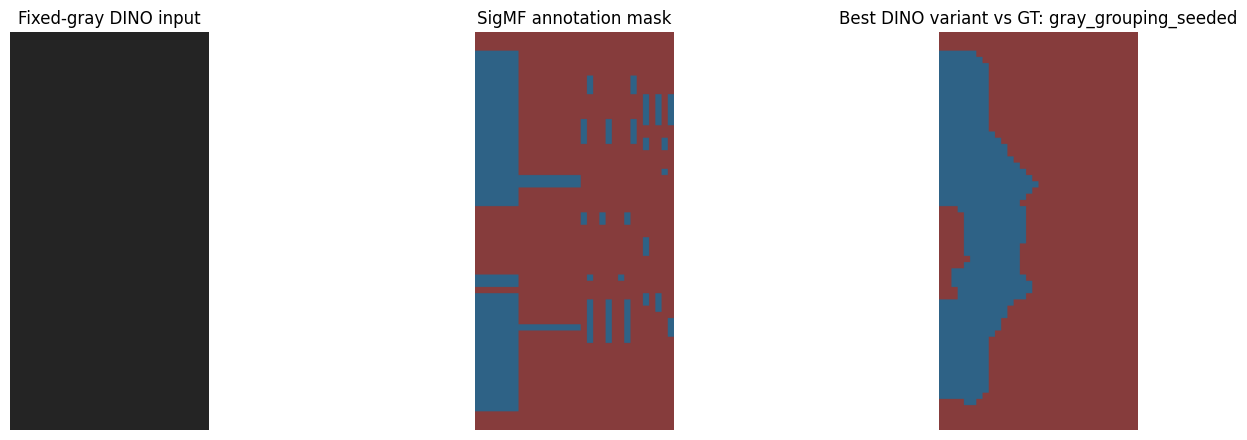

In [23]:
gt_patch_dino, gt_px_dino = sigmf_annotation_patch_mask(
    ann_overlaps,
    time_axis_s=t,
    freq_axis_hz=f,
    patch_h=run_gray_seeded['shape'][0],
    patch_w=run_gray_seeded['shape'][1],
    min_coverage=0.10,
)

dino_group_ground_truth_patch = gt_patch_dino.astype(np.uint8)

gt_overlay_dino = _overlay_from_mask(run_gray_seeded['input_img'], dino_group_ground_truth_patch)
best_dino_method = None
comparison_rows = []
for name, run in dino_group_runs.items():
    row = _spatial_metrics(run['mask'])
    row.update(binary_mask_metrics(run['mask'], dino_group_ground_truth_patch))
    row['method'] = name
    row['threshold'] = float(run['threshold'])
    row['mean_score'] = float(np.mean(run['score']))
    row['seed_mean'] = float(np.mean(run['seed_patch']))
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('method').sort_values(
    ['f1', 'iou', 'recall', 'precision'],
    ascending=False,
)
best_dino_method = comparison_df.index[0]

print(f'SigMF annotations overlapping current window: {len(ann_overlaps)}')
print('DINO grouping comparison metrics vs SigMF annotation boxes:')
display(comparison_df)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].imshow(run_gray_seeded['input_img'])
ax[0].set_title('Fixed-gray DINO input')
ax[0].axis('off')

ax[1].imshow(gt_overlay_dino)
ax[1].set_title('SigMF annotation mask')
ax[1].axis('off')

ax[2].imshow(dino_group_overlays[best_dino_method])
ax[2].set_title(f'Best DINO variant vs GT: {best_dino_method}')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## DINO Region Grouping Improvements

This section switches DINO from global anomaly ranking to patch-affinity grouping.

The revised DINO path does four things:
1. Uses a fixed grayscale dB rendering instead of pseudo-color.
2. Builds a patch graph from DINO feature similarity plus spatial adjacency.
3. Uses a weak spectrogram-derived seed prior only to choose the signal-like group.
4. Produces a grouping/coherence score rather than a pure distance-to-neighbors anomaly score.

In [10]:
from sklearn.neighbors import NearestNeighbors
from scipy import ndimage

# ---- Utility helpers ----
def _to_patch_map_from_pixel_mask(mask_px, patch_h, patch_w, threshold=0.25):
    h_px, w_px = mask_px.shape
    bh = h_px // patch_h
    bw = w_px // patch_w
    m = mask_px[: patch_h * bh, : patch_w * bw]
    m = m.reshape(patch_h, bh, patch_w, bw).mean(axis=(1, 3))
    return (m >= threshold).astype(np.uint8)


def _overlay_patch_mask(img_rgb, patch_mask, alpha=0.45):
    up = Image.fromarray((patch_mask * 255).astype(np.uint8), mode='L').resize(img_rgb.size, Image.NEAREST)
    mask = np.array(up) >= 128
    base = np.array(img_rgb).astype(np.float32)
    out = base.copy()
    c0 = np.array([255, 90, 90], dtype=np.float32)
    c1 = np.array([60, 175, 255], dtype=np.float32)
    out[~mask] = (1 - alpha) * out[~mask] + alpha * c0
    out[mask] = (1 - alpha) * out[mask] + alpha * c1
    return out.astype(np.uint8)


def _smoothness_metrics(mask_patch):
    v_dis = np.mean(mask_patch[1:, :] != mask_patch[:-1, :])
    h_dis = np.mean(mask_patch[:, 1:] != mask_patch[:, :-1])
    edge_dis = 0.5 * (v_dis + h_dis)
    comp0, n0 = ndimage.label(mask_patch == 0)
    comp1, n1 = ndimage.label(mask_patch == 1)
    return {
        'smoothness': 1.0 - edge_dis,
        'edge_disagreement': edge_dis,
        'num_components': int(n0 + n1),
        'foreground_fraction': float(mask_patch.mean()),
    }


def robust_pca_like_mask(sxx_db_local, rank=8, q=0.95):
    X = sxx_db_local.astype(np.float32)
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    r = min(rank, len(S))
    L = (U[:, :r] * S[:r]) @ Vt[:r, :]
    R = np.abs(X - L)
    thr = np.quantile(R, q)
    return R >= thr


def nonlocal_texture_recurrence_mask(img_rgb, patch_h, patch_w, patch_size, k=6, q=0.90):
    gray = np.array(img_rgb.convert('L')).astype(np.float32) / 255.0
    H = patch_h * patch_size
    W = patch_w * patch_size
    gray = gray[:H, :W]
    patches = gray.reshape(patch_h, patch_size, patch_w, patch_size).transpose(0, 2, 1, 3).reshape(-1, patch_size * patch_size)

    patches = patches - patches.mean(axis=1, keepdims=True)
    patches = patches / np.maximum(patches.std(axis=1, keepdims=True), 1e-6)

    nn = NearestNeighbors(n_neighbors=min(k + 1, patches.shape[0]), metric='cosine')
    nn.fit(patches)
    dist, _ = nn.kneighbors(patches)
    rec_score = dist[:, 1:].mean(axis=1)
    thr = np.quantile(rec_score, q)
    mask = (rec_score >= thr).astype(np.uint8)
    return mask.reshape(patch_h, patch_w), rec_score.reshape(patch_h, patch_w)


def cfar_like_mask(sxx_db_local, guard=2, train=8, alpha=3.0):
    P = np.power(10.0, sxx_db_local / 10.0).astype(np.float32)

    win = 2 * (guard + train) + 1
    guard_win = 2 * guard + 1

    kernel_train = np.ones((win, win), dtype=np.float32)
    g0 = train
    g1 = train + guard_win
    kernel_train[g0:g1, g0:g1] = 0.0

    train_count = kernel_train.sum()
    sum_train = ndimage.convolve(P, kernel_train, mode='reflect')
    mu = sum_train / max(train_count, 1.0)

    det = P > (alpha * mu)
    return det


patch_h = resized_img.size[1] // DINO_PATCH_SIZE
patch_w = resized_img.size[0] // DINO_PATCH_SIZE

mask_rpca_px = robust_pca_like_mask(sxx_db, rank=8, q=0.95)
mask_rpca = _to_patch_map_from_pixel_mask(mask_rpca_px, patch_h, patch_w, threshold=0.25)

dino_group = dino_grouping_from_spectrogram(
    sxx_db,
    db_min=-110.0,
    db_max=-40.0,
    feature_knn=8,
    spatial_weight=0.35,
    score_q=0.60,
    use_seed=True,
    smooth_iters=2,
    min_component_size=6,
    random_state=42,
)
mask_dino_group = dino_group['mask']
score_dino_group = dino_group['score']

mask_tex, score_tex = nonlocal_texture_recurrence_mask(
    resized_img,
    patch_h,
    patch_w,
    DINO_PATCH_SIZE,
    k=6,
    q=0.90,
)

mask_cfar_px = cfar_like_mask(sxx_db, guard=2, train=8, alpha=3.0)
mask_cfar = _to_patch_map_from_pixel_mask(mask_cfar_px, patch_h, patch_w, threshold=0.25)

literature_masks = {
    'robust_pca': mask_rpca,
    'dino_region_grouping': mask_dino_group,
    'texture_nonlocal': mask_tex,
    'cfar_like': mask_cfar,
}

literature_overlays = {
    'robust_pca': _overlay_patch_mask(resized_img, mask_rpca),
    'dino_region_grouping': _overlay_patch_mask(dino_group['input_img'], mask_dino_group),
    'texture_nonlocal': _overlay_patch_mask(resized_img, mask_tex),
    'cfar_like': _overlay_patch_mask(resized_img, mask_cfar),
}

print('Literature-aligned methods computed with DINO region grouping.')

Literature-aligned methods computed with DINO region grouping.


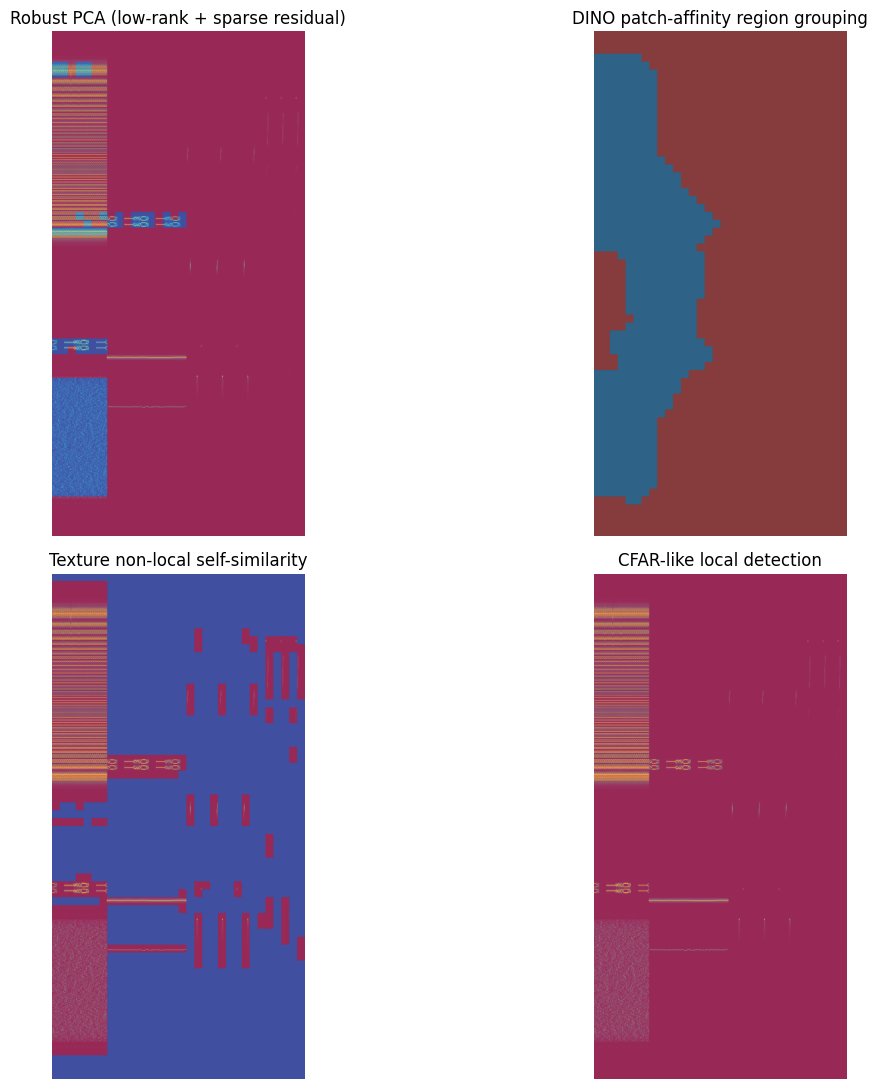

Literature-aligned mask metrics:


,smoothness,edge_disagreement,num_components,foreground_fraction
method,,,,
cfar_like,1.000000,0.000000,1,0.000000
robust_pca,0.971046,0.028954,11,0.073242
dino_region_grouping,0.969202,0.030798,3,0.270020
texture_nonlocal,0.896085,0.103915,27,0.749512


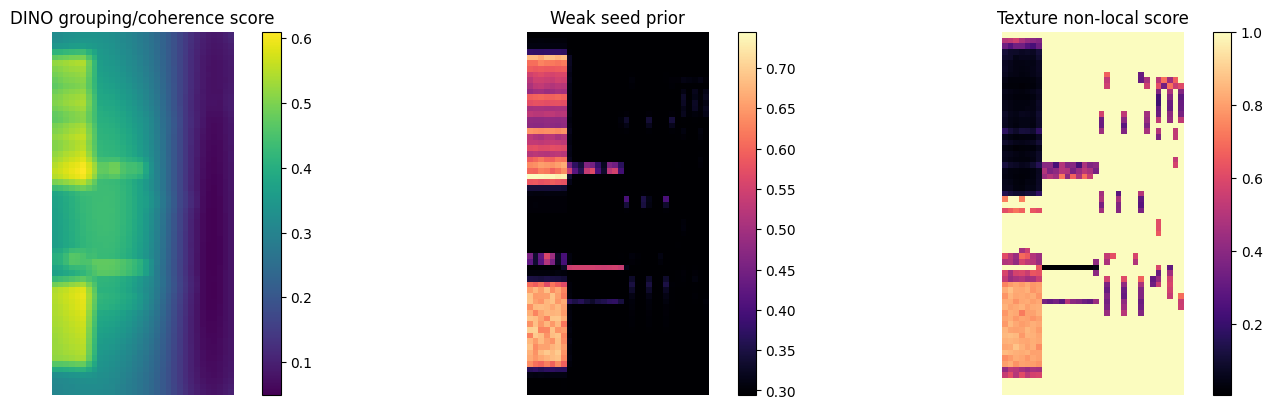

In [11]:
# Visual + metric comparison for the literature-aligned methods
fig, ax = plt.subplots(2, 2, figsize=(14, 11))

ax[0, 0].imshow(literature_overlays['robust_pca'])
ax[0, 0].set_title('Robust PCA (low-rank + sparse residual)')
ax[0, 0].axis('off')

ax[0, 1].imshow(literature_overlays['dino_region_grouping'])
ax[0, 1].set_title('DINO patch-affinity region grouping')
ax[0, 1].axis('off')

ax[1, 0].imshow(literature_overlays['texture_nonlocal'])
ax[1, 0].set_title('Texture non-local self-similarity')
ax[1, 0].axis('off')

ax[1, 1].imshow(literature_overlays['cfar_like'])
ax[1, 1].set_title('CFAR-like local detection')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

lit_rows = []
for name, mask in literature_masks.items():
    m = _smoothness_metrics(mask)
    m['method'] = name
    lit_rows.append(m)

literature_df = pd.DataFrame(lit_rows).set_index('method').sort_values('foreground_fraction')
print('Literature-aligned mask metrics:')
display(literature_df)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
im0 = ax[0].imshow(score_dino_group, cmap='viridis')
ax[0].set_title('DINO grouping/coherence score')
ax[0].axis('off')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(dino_group['seed_patch'], cmap='magma')
ax[1].set_title('Weak seed prior')
ax[1].axis('off')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(score_tex, cmap='magma')
ax[2].set_title('Texture non-local score')
ax[2].axis('off')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

plt.tight_layout()
plt.show()

In [24]:
lit_shape = next(iter(literature_masks.values())).shape
gt_patch_lit, gt_px_lit = sigmf_annotation_patch_mask(
    ann_overlaps,
    time_axis_s=t,
    freq_axis_hz=f,
    patch_h=lit_shape[0],
    patch_w=lit_shape[1],
    min_coverage=0.10,
)

literature_rows = []
for name, mask in literature_masks.items():
    row = _smoothness_metrics(mask)
    row.update(binary_mask_metrics(mask, gt_patch_lit))
    row['method'] = name
    literature_rows.append(row)

literature_df = pd.DataFrame(literature_rows).set_index('method').sort_values(
    ['f1', 'iou', 'recall', 'precision'],
    ascending=False,
)
print('Literature-aligned mask metrics vs SigMF annotation boxes:')
display(literature_df[['iou', 'f1', 'precision', 'recall', 'foreground_fraction', 'smoothness']])

Literature-aligned mask metrics vs SigMF annotation boxes:


,iou,f1,precision,recall,foreground_fraction,smoothness
method,,,,,,
dino_region_grouping,0.487141,0.655137,0.582278,0.748837,0.270020,0.969202
robust_pca,0.348837,0.517241,1.000000,0.348837,0.073242,0.971046
texture_nonlocal,0.000509,0.001018,0.000651,0.002326,0.749512,0.896085
cfar_like,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


## Texture + DINO Grouping Stress Test: SNR Sweep

This experiment runs an end-to-end pipeline for SNR values from **30 dB to -40 dB** in **10 dB** steps:
1. Add controlled AWGN to complex IQ data.
2. Generate the spectrogram with FFT size 1024.
3. Feed DINO a fixed grayscale dB rendering.
4. Compute the texture branch and the revised DINO grouping/coherence branch.
5. Build patch masks and compare them across SNR.

In [31]:
# --- Standard AWGN SNR stress-test config ---
from scipy import ndimage

SNR_SWEEP_DB = list(range(30, -41, -10))
TEXTURE_Q = 0.90
TEXTURE_K = 6

WHITEHAT_Q = 0.90
WHITEHAT_OPEN_FREQ = 9
WHITEHAT_OPEN_TIME = 9

DINO_GROUP_K = 8
DINO_GROUP_SPATIAL_WEIGHT = 0.35
DINO_GROUP_SCORE_Q = 0.60
DINO_GROUP_DB_LOW_Q = 1.0
DINO_GROUP_DB_HIGH_Q = 99.0
DINO_GROUP_DB_MIN_SPAN = 12.0
DINO_GROUP_DB_FLOOR = -140.0
DINO_GROUP_DB_CEIL = -20.0

HYBRID_Q = 0.90
HYBRID_TEXTURE_SNR_MIN = -15.0
HYBRID_TEXTURE_SNR_MAX = 20.0
HYBRID_POWER_WEIGHT = 0.20
HYBRID_SIGNALNESS_WEIGHT = 0.20
HYBRID_NORM_LOW_Q = 5.0
HYBRID_NORM_HIGH_Q = 95.0

NOISE_SEED = 42

ORIG_NOISE_Q = 20.0
ORIG_NOISE_TRIM_HIGH_Q = 80.0
ORIG_NOISE_DB_MIN = -140.0
ORIG_NOISE_DB_MAX = -20.0
ORIG_DYN_LOW_Q = 1.0
ORIG_DYN_HIGH_Q = 99.0

USE_FIXED_MODEL_DB_WINDOW = False
MODEL_DB_LOW_Q = 1.0
MODEL_DB_HIGH_Q = 99.0
MODEL_DB_MIN_SPAN = 10.0
MODEL_DB_FLOOR = -160.0
MODEL_DB_CEIL = -20.0

USE_SOFT_AUTO_DB_SCALE = False
AUTO_DB_LOW_Q = 1.0
AUTO_DB_HIGH_Q = 99.0
AUTO_DB_CONTRAST_FLOOR = 6.0
AUTO_DB_FLOOR = -140.0
AUTO_DB_CEIL = -20.0


def robust_fixed_db_window(
    sxx_frame_db,
    low_q=1.0,
    high_q=99.0,
    min_span_db=10.0,
    floor_db=-160.0,
    ceil_db=-20.0,
):
    vals = np.asarray(sxx_frame_db, dtype=np.float32).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -110.0, -100.0

    lo = float(np.percentile(vals, low_q))
    hi = float(np.percentile(vals, high_q))
    if hi < lo:
        lo, hi = hi, lo

    lo = float(np.clip(lo, floor_db, ceil_db))
    hi = float(np.clip(hi, floor_db, ceil_db))

    span = max(hi - lo, float(min_span_db))
    span = min(span, float(ceil_db - floor_db))
    center = 0.5 * (lo + hi)
    half = 0.5 * span
    center = float(np.clip(center, floor_db + half, ceil_db - half))
    vmin = center - half
    vmax = center + half
    if vmax <= vmin:
        vmax = vmin + 1.0
    return float(vmin), float(vmax)


def soft_auto_db_window(
    sxx_frame_db,
    low_q=1.0,
    high_q=99.0,
    contrast_floor_db=6.0,
    floor_db=-140.0,
    ceil_db=-20.0,
):
    vals = np.asarray(sxx_frame_db, dtype=np.float32).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -110.0, -104.0, 0.0, 6.0

    lo = float(np.percentile(vals, low_q))
    hi = float(np.percentile(vals, high_q))
    if hi < lo:
        lo, hi = hi, lo

    lo = float(np.clip(lo, floor_db, ceil_db))
    hi = float(np.clip(hi, floor_db, ceil_db))

    raw_span = max(0.0, hi - lo)
    out_span = max(raw_span, float(contrast_floor_db))
    out_span = min(out_span, float(ceil_db - floor_db))

    center = 0.5 * (lo + hi)
    half = 0.5 * out_span
    center = float(np.clip(center, floor_db + half, ceil_db - half))
    vmin = center - half
    vmax = center + half

    if vmax <= vmin:
        vmax = vmin + 1.0

    return float(vmin), float(vmax), float(raw_span), float(out_span)


def estimate_original_noise_floor_db(
    sxx_db_local,
    q=20.0,
    trim_high_q=80.0,
    floor_db_min=-140.0,
    floor_db_max=-20.0,
):
    vals = np.asarray(sxx_db_local, dtype=np.float32).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -100.0

    hi_cap = float(np.percentile(vals, trim_high_q))
    vals_trim = vals[vals <= hi_cap]
    if vals_trim.size < 32:
        vals_trim = vals

    floor_db = float(np.percentile(vals_trim, q))
    return float(np.clip(floor_db, floor_db_min, floor_db_max))


def estimate_original_snr_from_iq(iq_clean, sxx_db_local, noise_floor_db):
    p_total = float(np.mean(np.abs(iq_clean.astype(np.complex64)) ** 2))
    p_noise = float(10.0 ** (noise_floor_db / 10.0))
    p_signal = max(p_total - p_noise, 1e-20)
    snr_db = float(10.0 * np.log10(p_signal / max(p_noise, 1e-20)))
    dyn_db = float(np.percentile(sxx_db_local, ORIG_DYN_HIGH_Q) - np.percentile(sxx_db_local, ORIG_DYN_LOW_Q))
    return p_signal, p_noise, p_total, snr_db, dyn_db


def add_awgn_for_target_snr(iq_clean, p_signal_est, p_noise_orig_est, target_snr_db, rng):
    target_linear = float(10.0 ** (target_snr_db / 10.0))
    p_noise_total_target = p_signal_est / max(target_linear, 1e-20)
    p_noise_add = max(p_noise_total_target - p_noise_orig_est, 0.0)

    sigma = np.sqrt(p_noise_add / 2.0)
    awgn = (
        rng.normal(0.0, sigma, size=iq_clean.shape) + 1j * rng.normal(0.0, sigma, size=iq_clean.shape)
    ).astype(np.complex64)

    y = iq_clean.astype(np.complex64) + awgn
    p_noise_total_est = p_noise_orig_est + p_noise_add
    actual_snr_est_db = float(10.0 * np.log10(max(p_signal_est, 1e-20) / max(p_noise_total_est, 1e-20)))
    return y, float(p_noise_add), float(p_noise_total_est), actual_snr_est_db


def whitehat_spectrogram_mask(sxx_db_local, patch_h, patch_w, open_freq=9, open_time=9, q=0.90):
    score_px = sxx_db_local.astype(np.float32) - ndimage.grey_opening(
        sxx_db_local.astype(np.float32),
        size=(int(open_freq), int(open_time)),
    )
    score_patch = patch_mean_map(score_px, patch_h, patch_w)
    mask_patch = (score_patch >= np.quantile(score_patch, q)).astype(np.uint8)
    thr = float(np.quantile(score_patch, q))
    return mask_patch, score_patch.astype(np.float32), thr


def normalize_map_01(x, low_q=5.0, high_q=95.0):
    x = np.asarray(x, dtype=np.float32)
    vals = x[np.isfinite(x)]
    if vals.size == 0:
        return np.zeros_like(x, dtype=np.float32)
    lo = float(np.percentile(vals, low_q))
    hi = float(np.percentile(vals, high_q))
    if hi <= lo:
        hi = lo + 1e-6
    out = (x - lo) / (hi - lo)
    return np.clip(out, 0.0, 1.0).astype(np.float32)


def power_prior_patch_map(sxx_db_local, patch_h, patch_w):
    p_lin = np.power(10.0, np.asarray(sxx_db_local, dtype=np.float32) / 10.0)
    p_floor = max(float(np.percentile(p_lin, 30.0)), 1e-20)
    rel_db = 10.0 * np.log10(np.maximum(p_lin, 1e-20) / p_floor)
    rel_db = np.clip(rel_db, -5.0, 25.0)
    return patch_mean_map(rel_db, patch_h, patch_w)


def signalness_prior_patch_map(sxx_db_local, patch_h, patch_w):
    x_db = np.asarray(sxx_db_local, dtype=np.float32)
    p_lin = np.power(10.0, x_db / 10.0)
    p_lin = np.maximum(p_lin, 1e-20)

    p_col = p_lin / np.maximum(np.sum(p_lin, axis=0, keepdims=True), 1e-20)
    ent = -np.sum(p_col * np.log(np.maximum(p_col, 1e-20)), axis=0)
    ent = ent / np.log(max(2, p_col.shape[0]))
    concentration_t = 1.0 - ent
    concentration_px = np.tile(concentration_t[None, :], (p_lin.shape[0], 1)).astype(np.float32)

    rel_db = 10.0 * np.log10(p_lin / np.maximum(np.percentile(p_lin, 30.0), 1e-20))
    rel_db = np.clip(rel_db, -10.0, 30.0)
    persistence_px = ndimage.uniform_filter(rel_db, size=(1, 7), mode='nearest').astype(np.float32)

    smooth_px = ndimage.uniform_filter(x_db, size=(3, 3), mode='nearest')
    resid_px = np.abs(x_db - smooth_px)
    predictability_px = -resid_px.astype(np.float32)

    env = rel_db - rel_db.mean(axis=1, keepdims=True)
    var = np.mean(env ** 2, axis=1) + 1e-8
    ac1 = np.mean(env[:, 1:] * env[:, :-1], axis=1) / var
    ac2 = np.mean(env[:, 2:] * env[:, :-2], axis=1) / var
    cyc_f = np.clip(0.5 * (ac1 + ac2), -1.0, 1.0)
    cyc_px = np.tile(cyc_f[:, None], (1, p_lin.shape[1])).astype(np.float32)

    conc_n = normalize_map_01(concentration_px, HYBRID_NORM_LOW_Q, HYBRID_NORM_HIGH_Q)
    pers_n = normalize_map_01(persistence_px, HYBRID_NORM_LOW_Q, HYBRID_NORM_HIGH_Q)
    pred_n = normalize_map_01(predictability_px, HYBRID_NORM_LOW_Q, HYBRID_NORM_HIGH_Q)
    cyc_n = normalize_map_01(cyc_px, HYBRID_NORM_LOW_Q, HYBRID_NORM_HIGH_Q)

    signalness_px = (0.30 * conc_n + 0.30 * pers_n + 0.20 * pred_n + 0.20 * cyc_n).astype(np.float32)
    return patch_mean_map(signalness_px, patch_h, patch_w)


def hybrid_weights_from_snr(snr_db):
    alpha = float(np.clip(
        (snr_db - HYBRID_TEXTURE_SNR_MIN) / max(HYBRID_TEXTURE_SNR_MAX - HYBRID_TEXTURE_SNR_MIN, 1e-6),
        0.0,
        1.0,
    ))
    w_tex = 0.20 + 0.35 * alpha
    w_dino = 0.60 - 0.35 * alpha
    w_power = float(HYBRID_POWER_WEIGHT)
    w_signal = float(HYBRID_SIGNALNESS_WEIGHT)
    s = w_tex + w_dino + w_power + w_signal
    return float(w_tex / s), float(w_dino / s), float(w_power / s), float(w_signal / s)


def hybrid_fusion_from_components(texture_score_patch, dino_score_patch, power_score_patch, signalness_score_patch, snr_db):
    tex_n = normalize_map_01(texture_score_patch, HYBRID_NORM_LOW_Q, HYBRID_NORM_HIGH_Q)
    dino_n = normalize_map_01(dino_score_patch, HYBRID_NORM_LOW_Q, HYBRID_NORM_HIGH_Q)
    power_n = normalize_map_01(power_score_patch, HYBRID_NORM_LOW_Q, HYBRID_NORM_HIGH_Q)
    signal_n = normalize_map_01(signalness_score_patch, HYBRID_NORM_LOW_Q, HYBRID_NORM_HIGH_Q)

    w_tex, w_dino, w_power, w_signal = hybrid_weights_from_snr(snr_db)
    tex_c = (w_tex * tex_n).astype(np.float32)
    dino_c = (w_dino * dino_n).astype(np.float32)
    power_c = (w_power * power_n).astype(np.float32)
    signal_c = (w_signal * signal_n).astype(np.float32)

    hybrid_score = (tex_c + dino_c + power_c + signal_c).astype(np.float32)
    thr = float(np.quantile(hybrid_score, HYBRID_Q))
    hybrid_mask = (hybrid_score >= thr).astype(np.uint8)

    return {
        'hybrid_score': hybrid_score,
        'hybrid_mask': hybrid_mask,
        'hybrid_threshold': thr,
        'w_texture': w_tex,
        'w_dino': w_dino,
        'w_power': w_power,
        'w_signalness': w_signal,
        'texture_norm': tex_n,
        'dino_norm': dino_n,
        'power_norm': power_n,
        'signalness_norm': signal_n,
        'texture_contrib': tex_c,
        'dino_contrib': dino_c,
        'power_contrib': power_c,
        'signalness_contrib': signal_c,
    }


def load_chunk_for_file(meta_path, start_s, duration_s):
    iq_local, params_local = load_sigmf_samples(
        meta_path,
        start_s=start_s,
        duration_s=duration_s,
        capture_index=0,
        channel=0,
    )
    fs_local = float(params_local['sample_rate'])
    cf_local = params_local.get('center_frequency', None)
    return iq_local.astype(np.complex64), fs_local, cf_local


sweep_meta_path = Path(SIGMF_META_PATH)
if not sweep_meta_path.exists():
    raise FileNotFoundError(f'Configured SIGMF_META_PATH does not exist: {sweep_meta_path}')

sweep_start_s = float(SAMPLE_OFFSET_S)
iq_sweep, sweep_fs, sweep_center_frequency = load_chunk_for_file(
    meta_path=sweep_meta_path,
    start_s=sweep_start_s,
    duration_s=chunk_seconds,
)

_, _, sxx_selected = generate_spectrogram(
    iq_sweep,
    fs=sweep_fs,
    nperseg=FFT_SIZE,
    noverlap=NOVERLAP,
    center_frequency=sweep_center_frequency,
)
selected_span_db = float(np.percentile(sxx_selected, 99.0) - np.percentile(sxx_selected, 1.0))
print(
    f'Sweep source: {sweep_meta_path} | start: {sweep_start_s:.3f} s | '
    f'contrast span (1-99 pct): {selected_span_db:.4f} dB'
)

iq_clean = iq_sweep.copy()
rng = np.random.default_rng(NOISE_SEED)

_, _, sxx_orig_db = generate_spectrogram(
    iq_clean,
    fs=sweep_fs,
    nperseg=FFT_SIZE,
    noverlap=NOVERLAP,
    center_frequency=sweep_center_frequency,
)
orig_noise_floor_db = estimate_original_noise_floor_db(
    sxx_orig_db,
    q=ORIG_NOISE_Q,
    trim_high_q=ORIG_NOISE_TRIM_HIGH_Q,
    floor_db_min=ORIG_NOISE_DB_MIN,
    floor_db_max=ORIG_NOISE_DB_MAX,
)
p_signal_est, p_noise_orig_est, p_total_est, orig_snr_db, orig_dyn_db = estimate_original_snr_from_iq(
    iq_clean,
    sxx_orig_db,
    orig_noise_floor_db,
)

dino_vmin, dino_vmax = robust_fixed_db_window(
    sxx_orig_db,
    low_q=DINO_GROUP_DB_LOW_Q,
    high_q=DINO_GROUP_DB_HIGH_Q,
    min_span_db=DINO_GROUP_DB_MIN_SPAN,
    floor_db=DINO_GROUP_DB_FLOOR,
    ceil_db=DINO_GROUP_DB_CEIL,
)

if USE_FIXED_MODEL_DB_WINDOW:
    model_vmin, model_vmax = robust_fixed_db_window(
        sxx_orig_db,
        low_q=MODEL_DB_LOW_Q,
        high_q=MODEL_DB_HIGH_Q,
        min_span_db=MODEL_DB_MIN_SPAN,
        floor_db=MODEL_DB_FLOOR,
        ceil_db=MODEL_DB_CEIL,
    )
else:
    model_vmin, model_vmax = np.nan, np.nan

snr_results = []
for snr_db in SNR_SWEEP_DB:
    noisy_iq, p_noise_added, p_noise_total_est, actual_snr_db = add_awgn_for_target_snr(
        iq_clean=iq_clean,
        p_signal_est=p_signal_est,
        p_noise_orig_est=p_noise_orig_est,
        target_snr_db=snr_db,
        rng=rng,
    )

    f_snr, t_snr, sxx_snr_db = generate_spectrogram(
        noisy_iq,
        fs=sweep_fs,
        nperseg=FFT_SIZE,
        noverlap=NOVERLAP,
        center_frequency=sweep_center_frequency,
    )

    if USE_FIXED_MODEL_DB_WINDOW:
        spec_model_img, _, _ = spectrogram_to_rgb(sxx_snr_db, vmin=model_vmin, vmax=model_vmax)
    else:
        spec_model_img, _, _ = spectrogram_to_rgb(sxx_snr_db)

    if USE_SOFT_AUTO_DB_SCALE:
        frame_vmin, frame_vmax, frame_dyn_range, out_span = soft_auto_db_window(
            sxx_snr_db,
            low_q=AUTO_DB_LOW_Q,
            high_q=AUTO_DB_HIGH_Q,
            contrast_floor_db=AUTO_DB_CONTRAST_FLOOR,
            floor_db=AUTO_DB_FLOOR,
            ceil_db=AUTO_DB_CEIL,
        )
        human_display_img, _, _ = spectrogram_to_rgb(sxx_snr_db, vmin=frame_vmin, vmax=frame_vmax)
    else:
        human_display_img = spec_model_img
        frame_vmin = float(model_vmin) if np.isfinite(model_vmin) else np.nan
        frame_vmax = float(model_vmax) if np.isfinite(model_vmax) else np.nan
        frame_dyn_range, out_span = np.nan, np.nan

    dino_input_img = _db_to_fixed_grayscale_rgb(sxx_snr_db, db_min=dino_vmin, db_max=dino_vmax)
    feat_snr, gh_snr, gw_snr, dino_input_img = _extract_dino_features_from_rgb(dino_input_img)

    mask_snr, score_snr = nonlocal_texture_recurrence_mask(
        spec_model_img,
        patch_h=gh_snr,
        patch_w=gw_snr,
        patch_size=DINO_PATCH_SIZE,
        k=TEXTURE_K,
        q=TEXTURE_Q,
    )
    score_snr = -score_snr.astype(np.float32)
    thr_snr = float(np.quantile(score_snr, TEXTURE_Q))
    mask_snr = (score_snr >= thr_snr).astype(np.uint8)

    dino_seed_snr = dino_seed_patch_map(sxx_snr_db, gh_snr, gw_snr)
    dino_group = dino_region_grouping_mask(
        feat_snr,
        patch_h=gh_snr,
        patch_w=gw_snr,
        seed_patch=dino_seed_snr,
        feature_knn=DINO_GROUP_K,
        spatial_weight=DINO_GROUP_SPATIAL_WEIGHT,
        score_q=DINO_GROUP_SCORE_Q,
        smooth_iters=2,
        min_component_size=6,
        random_state=42,
    )
    mask_dino_snr = dino_group['mask']
    score_dino_snr = dino_group['score']

    mask_whitehat_snr, score_whitehat_snr, thr_whitehat = whitehat_spectrogram_mask(
        sxx_snr_db,
        patch_h=gh_snr,
        patch_w=gw_snr,
        open_freq=WHITEHAT_OPEN_FREQ,
        open_time=WHITEHAT_OPEN_TIME,
        q=WHITEHAT_Q,
    )

    power_score_snr = power_prior_patch_map(sxx_snr_db, gh_snr, gw_snr)
    signalness_score_snr = signalness_prior_patch_map(sxx_snr_db, gh_snr, gw_snr)
    hybrid = hybrid_fusion_from_components(
        texture_score_patch=score_snr,
        dino_score_patch=score_dino_snr,
        power_score_patch=power_score_snr,
        signalness_score_patch=signalness_score_snr,
        snr_db=actual_snr_db,
    )

    snr_results.append({
        'snr_db': snr_db,
        'actual_snr_db': actual_snr_db,
        'signal_power_est': p_signal_est,
        'noise_power_orig_est': p_noise_orig_est,
        'noise_power_added': p_noise_added,
        'noise_power_total_est': p_noise_total_est,
        'orig_snr_db': orig_snr_db,
        'orig_dyn_db': orig_dyn_db,
        'orig_noise_floor_db': orig_noise_floor_db,
        'sweep_meta_path': str(sweep_meta_path),
        'sweep_start_s': sweep_start_s,
        'sweep_span_db': selected_span_db,
        'spectrogram_db': sxx_snr_db,
        'spec_img': dino_input_img,
        'display_img': dino_input_img,
        'human_display_img': human_display_img,
        'model_vmin': float(model_vmin) if np.isfinite(model_vmin) else np.nan,
        'model_vmax': float(model_vmax) if np.isfinite(model_vmax) else np.nan,
        'display_vmin': float(frame_vmin),
        'display_vmax': float(frame_vmax),
        'frame_dyn_range_db': float(frame_dyn_range),
        'display_span_db': float(out_span),
        'dino_input_vmin': float(dino_vmin),
        'dino_input_vmax': float(dino_vmax),
        'mask': mask_snr,
        'score_map': score_snr,
        'dino_mask': mask_dino_snr,
        'dino_score_map': score_dino_snr,
        'dino_seed_map': dino_seed_snr,
        'dino_threshold': float(dino_group['threshold']),
        'whitehat_mask': mask_whitehat_snr,
        'whitehat_score_map': score_whitehat_snr,
        'whitehat_threshold': thr_whitehat,
        'power_score_map': power_score_snr,
        'signalness_score_map': signalness_score_snr,
        'hybrid_mask': hybrid['hybrid_mask'],
        'hybrid_score_map': hybrid['hybrid_score'],
        'hybrid_threshold': hybrid['hybrid_threshold'],
        'hybrid_w_texture': hybrid['w_texture'],
        'hybrid_w_dino': hybrid['w_dino'],
        'hybrid_w_power': hybrid['w_power'],
        'hybrid_w_signalness': hybrid['w_signalness'],
        'texture_norm_map': hybrid['texture_norm'],
        'dino_norm_map': hybrid['dino_norm'],
        'power_norm_map': hybrid['power_norm'],
        'signalness_norm_map': hybrid['signalness_norm'],
        'texture_contrib_map': hybrid['texture_contrib'],
        'dino_contrib_map': hybrid['dino_contrib'],
        'power_contrib_map': hybrid['power_contrib'],
        'signalness_contrib_map': hybrid['signalness_contrib'],
        'threshold': thr_snr,
        'foreground_fraction': float(mask_snr.mean()),
        'dino_foreground_fraction': float(mask_dino_snr.mean()),
        'whitehat_foreground_fraction': float(mask_whitehat_snr.mean()),
        'hybrid_foreground_fraction': float(hybrid['hybrid_mask'].mean()),
        'smoothness': float(_smoothness_metrics(mask_snr)['smoothness']),
        'dino_smoothness': float(_smoothness_metrics(mask_dino_snr)['smoothness']),
        'whitehat_smoothness': float(_smoothness_metrics(mask_whitehat_snr)['smoothness']),
        'hybrid_smoothness': float(_smoothness_metrics(hybrid['hybrid_mask'])['smoothness']),
        'shape': (gh_snr, gw_snr),
    })

snr_summary_df = pd.DataFrame([
    {
        'snr_db': r['snr_db'],
        'actual_snr_db': r['actual_snr_db'],
        'orig_snr_db': r['orig_snr_db'],
        'orig_dyn_db': r['orig_dyn_db'],
        'orig_noise_floor_db': r['orig_noise_floor_db'],
        'signal_power_est': r['signal_power_est'],
        'noise_power_orig_est': r['noise_power_orig_est'],
        'noise_power_added': r['noise_power_added'],
        'noise_power_total_est': r['noise_power_total_est'],
        'sweep_start_s': r['sweep_start_s'],
        'sweep_span_db': r['sweep_span_db'],
        'foreground_fraction': r['foreground_fraction'],
        'dino_foreground_fraction': r['dino_foreground_fraction'],
        'whitehat_foreground_fraction': r['whitehat_foreground_fraction'],
        'hybrid_foreground_fraction': r['hybrid_foreground_fraction'],
        'smoothness': r['smoothness'],
        'dino_smoothness': r['dino_smoothness'],
        'whitehat_smoothness': r['whitehat_smoothness'],
        'hybrid_smoothness': r['hybrid_smoothness'],
        'score_threshold': r['threshold'],
        'dino_score_threshold': r['dino_threshold'],
        'whitehat_score_threshold': r['whitehat_threshold'],
        'hybrid_score_threshold': r['hybrid_threshold'],
        'hybrid_w_texture': r['hybrid_w_texture'],
        'hybrid_w_dino': r['hybrid_w_dino'],
        'hybrid_w_power': r['hybrid_w_power'],
        'hybrid_w_signalness': r['hybrid_w_signalness'],
        'model_vmin': r['model_vmin'],
        'model_vmax': r['model_vmax'],
        'display_vmin': r['display_vmin'],
        'display_vmax': r['display_vmax'],
        'dino_input_vmin': r['dino_input_vmin'],
        'dino_input_vmax': r['dino_input_vmax'],
        'frame_dyn_range_db': r['frame_dyn_range_db'],
        'display_span_db': r['display_span_db'],
        'patch_shape': r['shape'],
    }
    for r in snr_results
]).sort_values('snr_db', ascending=False)

print('Completed SNR sweep runs:', len(snr_results))
print('Standard pipeline: estimate original dynamic range/SNR, add AWGN, regenerate spectrogram, run detection.')
print(
    f'Original estimates: SNR={orig_snr_db:.2f} dB | dynamic_range={orig_dyn_db:.2f} dB | '
    f'noise_floor={orig_noise_floor_db:.2f} dB'
)
if USE_SOFT_AUTO_DB_SCALE:
    display_mode = 'soft-auto pseudo-color display'
elif USE_FIXED_MODEL_DB_WINDOW:
    display_mode = 'fixed pseudo-color display window'
else:
    display_mode = 'standard per-frame pseudo-color display'
print(
    f'DINO fixed-gray window: [{dino_vmin:.2f}, {dino_vmax:.2f}] dB | '
    f'Display mode: {display_mode}'
)
print(
    f'Hybrid fusion: q={HYBRID_Q:.2f}, w_power={HYBRID_POWER_WEIGHT:.2f}, w_signalness={HYBRID_SIGNALNESS_WEIGHT:.2f}, '
    f'norm_q=[{HYBRID_NORM_LOW_Q:.0f}, {HYBRID_NORM_HIGH_Q:.0f}]'
)
display(snr_summary_df)

Sweep source: /home/sat3737/holoscan_demo_workspace/test_data/SIGINT_DAY_DEMO_all_16_Emitter_noNoise.sigmf-meta | start: 0.159 s | contrast span (1-99 pct): 0.0024 dB
Completed SNR sweep runs: 8
Standard pipeline: estimate original dynamic range/SNR, add AWGN, regenerate spectrogram, run detection.
Original estimates: SNR=33.40 dB | dynamic_range=0.00 dB | noise_floor=-100.00 dB
DINO fixed-gray window: [-106.00, -94.00] dB | Display mode: standard per-frame pseudo-color display
Hybrid fusion: q=0.90, w_power=0.20, w_signalness=0.20, norm_q=[5, 95]


,snr_db,actual_snr_db,orig_snr_db,orig_dyn_db,orig_noise_floor_db,signal_power_est,noise_power_orig_est,noise_power_added,noise_power_total_est,sweep_start_s,...,hybrid_w_signalness,model_vmin,model_vmax,display_vmin,display_vmax,dino_input_vmin,dino_input_vmax,frame_dyn_range_db,display_span_db,patch_shape
0,30,30.0,33.39566,0.002441,-100.000008,2.185572e-07,9.999982e-11,1.185574e-10,2.185572e-10,0.159,...,0.166667,NaN,NaN,NaN,NaN,-105.998787,-93.998787,NaN,NaN,"(64, 32)"
1,20,20.0,33.39566,0.002441,-100.000008,2.185572e-07,9.999982e-11,2.085573e-09,2.185572e-09,0.159,...,0.166667,NaN,NaN,NaN,NaN,-105.998787,-93.998787,NaN,NaN,"(64, 32)"
2,10,10.0,33.39566,0.002441,-100.000008,2.185572e-07,9.999982e-11,2.175572e-08,2.185572e-08,0.159,...,0.166667,NaN,NaN,NaN,NaN,-105.998787,-93.998787,NaN,NaN,"(64, 32)"
3,0,0.0,33.39566,0.002441,-100.000008,2.185572e-07,9.999982e-11,2.184572e-07,2.185572e-07,0.159,...,0.166667,NaN,NaN,NaN,NaN,-105.998787,-93.998787,NaN,NaN,"(64, 32)"
4,-10,-10.0,33.39566,0.002441,-100.000008,2.185572e-07,9.999982e-11,2.185472e-06,2.185572e-06,0.159,...,0.166667,NaN,NaN,NaN,NaN,-105.998787,-93.998787,NaN,NaN,"(64, 32)"
5,-20,-20.0,33.39566,0.002441,-100.000008,2.185572e-07,9.999982e-11,2.185562e-05,2.185572e-05,0.159,...,0.166667,NaN,NaN,NaN,NaN,-105.998787,-93.998787,NaN,NaN,"(64, 32)"
6,-30,-30.0,33.39566,0.002441,-100.000008,2.185572e-07,9.999982e-11,2.185571e-04,2.185572e-04,0.159,...,0.166667,NaN,NaN,NaN,NaN,-105.998787,-93.998787,NaN,NaN,"(64, 32)"
7,-40,-40.0,33.39566,0.002441,-100.000008,2.185572e-07,9.999982e-11,2.185572e-03,2.185572e-03,0.159,...,0.166667,NaN,NaN,NaN,NaN,-105.998787,-93.998787,NaN,NaN,"(64, 32)"


SigMF annotations overlapping sweep window: 36
SNR sweep evaluation vs SigMF annotation boxes:


,snr_db,actual_snr_db,gt_foreground_fraction,texture_iou,texture_f1,texture_precision,texture_recall,dino_iou,dino_f1,dino_precision,...,whitehat_precision,whitehat_recall,hybrid_iou,hybrid_f1,hybrid_precision,hybrid_recall,foreground_fraction,dino_foreground_fraction,whitehat_foreground_fraction,hybrid_foreground_fraction
0,30,30.0,0.209961,0.407982,0.579528,0.897561,0.427907,0.185520,0.312977,0.872340,...,0.951220,0.453488,0.423767,0.595276,0.921951,0.439535,0.100098,0.045898,0.100098,0.100098
1,20,20.0,0.209961,0.430180,0.601575,0.931707,0.444186,0.185520,0.312977,0.872340,...,0.951220,0.453488,0.443182,0.614173,0.951220,0.453488,0.100098,0.045898,0.100098,0.100098
2,10,10.0,0.209961,0.443182,0.614173,0.951220,0.453488,0.185520,0.312977,0.872340,...,0.951220,0.453488,0.443182,0.614173,0.951220,0.453488,0.100098,0.045898,0.100098,0.100098
3,0,0.0,0.209961,0.443182,0.614173,0.951220,0.453488,0.185520,0.312977,0.872340,...,0.951220,0.453488,0.426966,0.598425,0.926829,0.441860,0.100098,0.045898,0.100098,0.100098
4,-10,-10.0,0.209961,0.306584,0.469291,0.726829,0.346512,0.182232,0.308285,0.898876,...,0.951220,0.453488,0.383442,0.554331,0.858537,0.409302,0.100098,0.043457,0.100098,0.100098
5,-20,-20.0,0.209961,0.069024,0.129134,0.200000,0.095349,0.079764,0.147743,0.179402,...,0.317073,0.151163,0.133929,0.236220,0.365854,0.174419,0.100098,0.146973,0.100098,0.100098
6,-30,-30.0,0.209961,0.076271,0.141732,0.219512,0.104651,0.096855,0.176606,0.174208,...,0.234146,0.111628,0.072635,0.135433,0.209756,0.100000,0.100098,0.215820,0.100098,0.100098
7,-40,-40.0,0.209961,0.067227,0.125984,0.195122,0.093023,0.071642,0.133705,0.166667,...,0.234146,0.111628,0.065436,0.122835,0.190244,0.090698,0.100098,0.140625,0.100098,0.100098


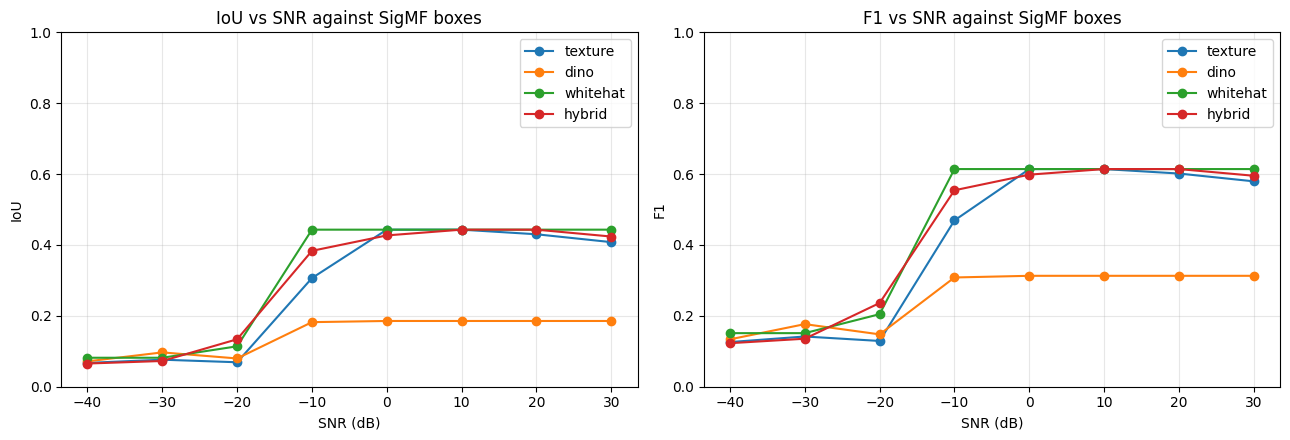

In [32]:
gt_ann_sweep = get_overlapping_sigmf_annotations(
    sweep_meta_path,
    window_start_s=sweep_start_s,
    window_duration_s=chunk_seconds,
    capture_index=0,
)
f_eval, t_eval, _ = generate_spectrogram(
    iq_clean,
    fs=sweep_fs,
    nperseg=FFT_SIZE,
    noverlap=NOVERLAP,
    center_frequency=sweep_center_frequency,
)

gt_patch_cache = {}
for r in snr_results:
    shape = tuple(r['shape'])
    if shape not in gt_patch_cache:
        gt_patch_cache[shape], _ = sigmf_annotation_patch_mask(
            gt_ann_sweep,
            time_axis_s=t_eval,
            freq_axis_hz=f_eval,
            patch_h=shape[0],
            patch_w=shape[1],
            min_coverage=0.10,
        )
    gt_patch = gt_patch_cache[shape]
    r['gt_mask'] = gt_patch.astype(np.uint8)

    for prefix, field in [
        ('texture', 'mask'),
        ('dino', 'dino_mask'),
        ('whitehat', 'whitehat_mask'),
        ('hybrid', 'hybrid_mask'),
    ]:
        metrics = binary_mask_metrics(r[field], gt_patch)
        for key, value in metrics.items():
            r[f'{prefix}_{key}'] = value

snr_eval_rows = []
for r in snr_results:
    snr_eval_rows.append({
        'snr_db': r['snr_db'],
        'actual_snr_db': r['actual_snr_db'],
        'gt_foreground_fraction': r['texture_gt_foreground_fraction'],
        'texture_iou': r['texture_iou'],
        'texture_f1': r['texture_f1'],
        'texture_precision': r['texture_precision'],
        'texture_recall': r['texture_recall'],
        'dino_iou': r['dino_iou'],
        'dino_f1': r['dino_f1'],
        'dino_precision': r['dino_precision'],
        'dino_recall': r['dino_recall'],
        'whitehat_iou': r['whitehat_iou'],
        'whitehat_f1': r['whitehat_f1'],
        'whitehat_precision': r['whitehat_precision'],
        'whitehat_recall': r['whitehat_recall'],
        'hybrid_iou': r['hybrid_iou'],
        'hybrid_f1': r['hybrid_f1'],
        'hybrid_precision': r['hybrid_precision'],
        'hybrid_recall': r['hybrid_recall'],
        'foreground_fraction': r['foreground_fraction'],
        'dino_foreground_fraction': r['dino_foreground_fraction'],
        'whitehat_foreground_fraction': r['whitehat_foreground_fraction'],
        'hybrid_foreground_fraction': r['hybrid_foreground_fraction'],
    })

snr_eval_df = pd.DataFrame(snr_eval_rows).sort_values('snr_db', ascending=False)
agg_df = snr_eval_df.copy()
snr_summary_df = snr_eval_df.copy()

print(f'SigMF annotations overlapping sweep window: {len(gt_ann_sweep)}')
print('SNR sweep evaluation vs SigMF annotation boxes:')
display(snr_eval_df)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for method in ['texture', 'dino', 'whitehat', 'hybrid']:
    ax[0].plot(snr_eval_df['snr_db'], snr_eval_df[f'{method}_iou'], marker='o', label=method)
    ax[1].plot(snr_eval_df['snr_db'], snr_eval_df[f'{method}_f1'], marker='o', label=method)

ax[0].set_title('IoU vs SNR against SigMF boxes')
ax[0].set_xlabel('SNR (dB)')
ax[0].set_ylabel('IoU')
ax[0].set_ylim(0.0, 1.0)
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].set_title('F1 vs SNR against SigMF boxes')
ax[1].set_xlabel('SNR (dB)')
ax[1].set_ylabel('F1')
ax[1].set_ylim(0.0, 1.0)
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

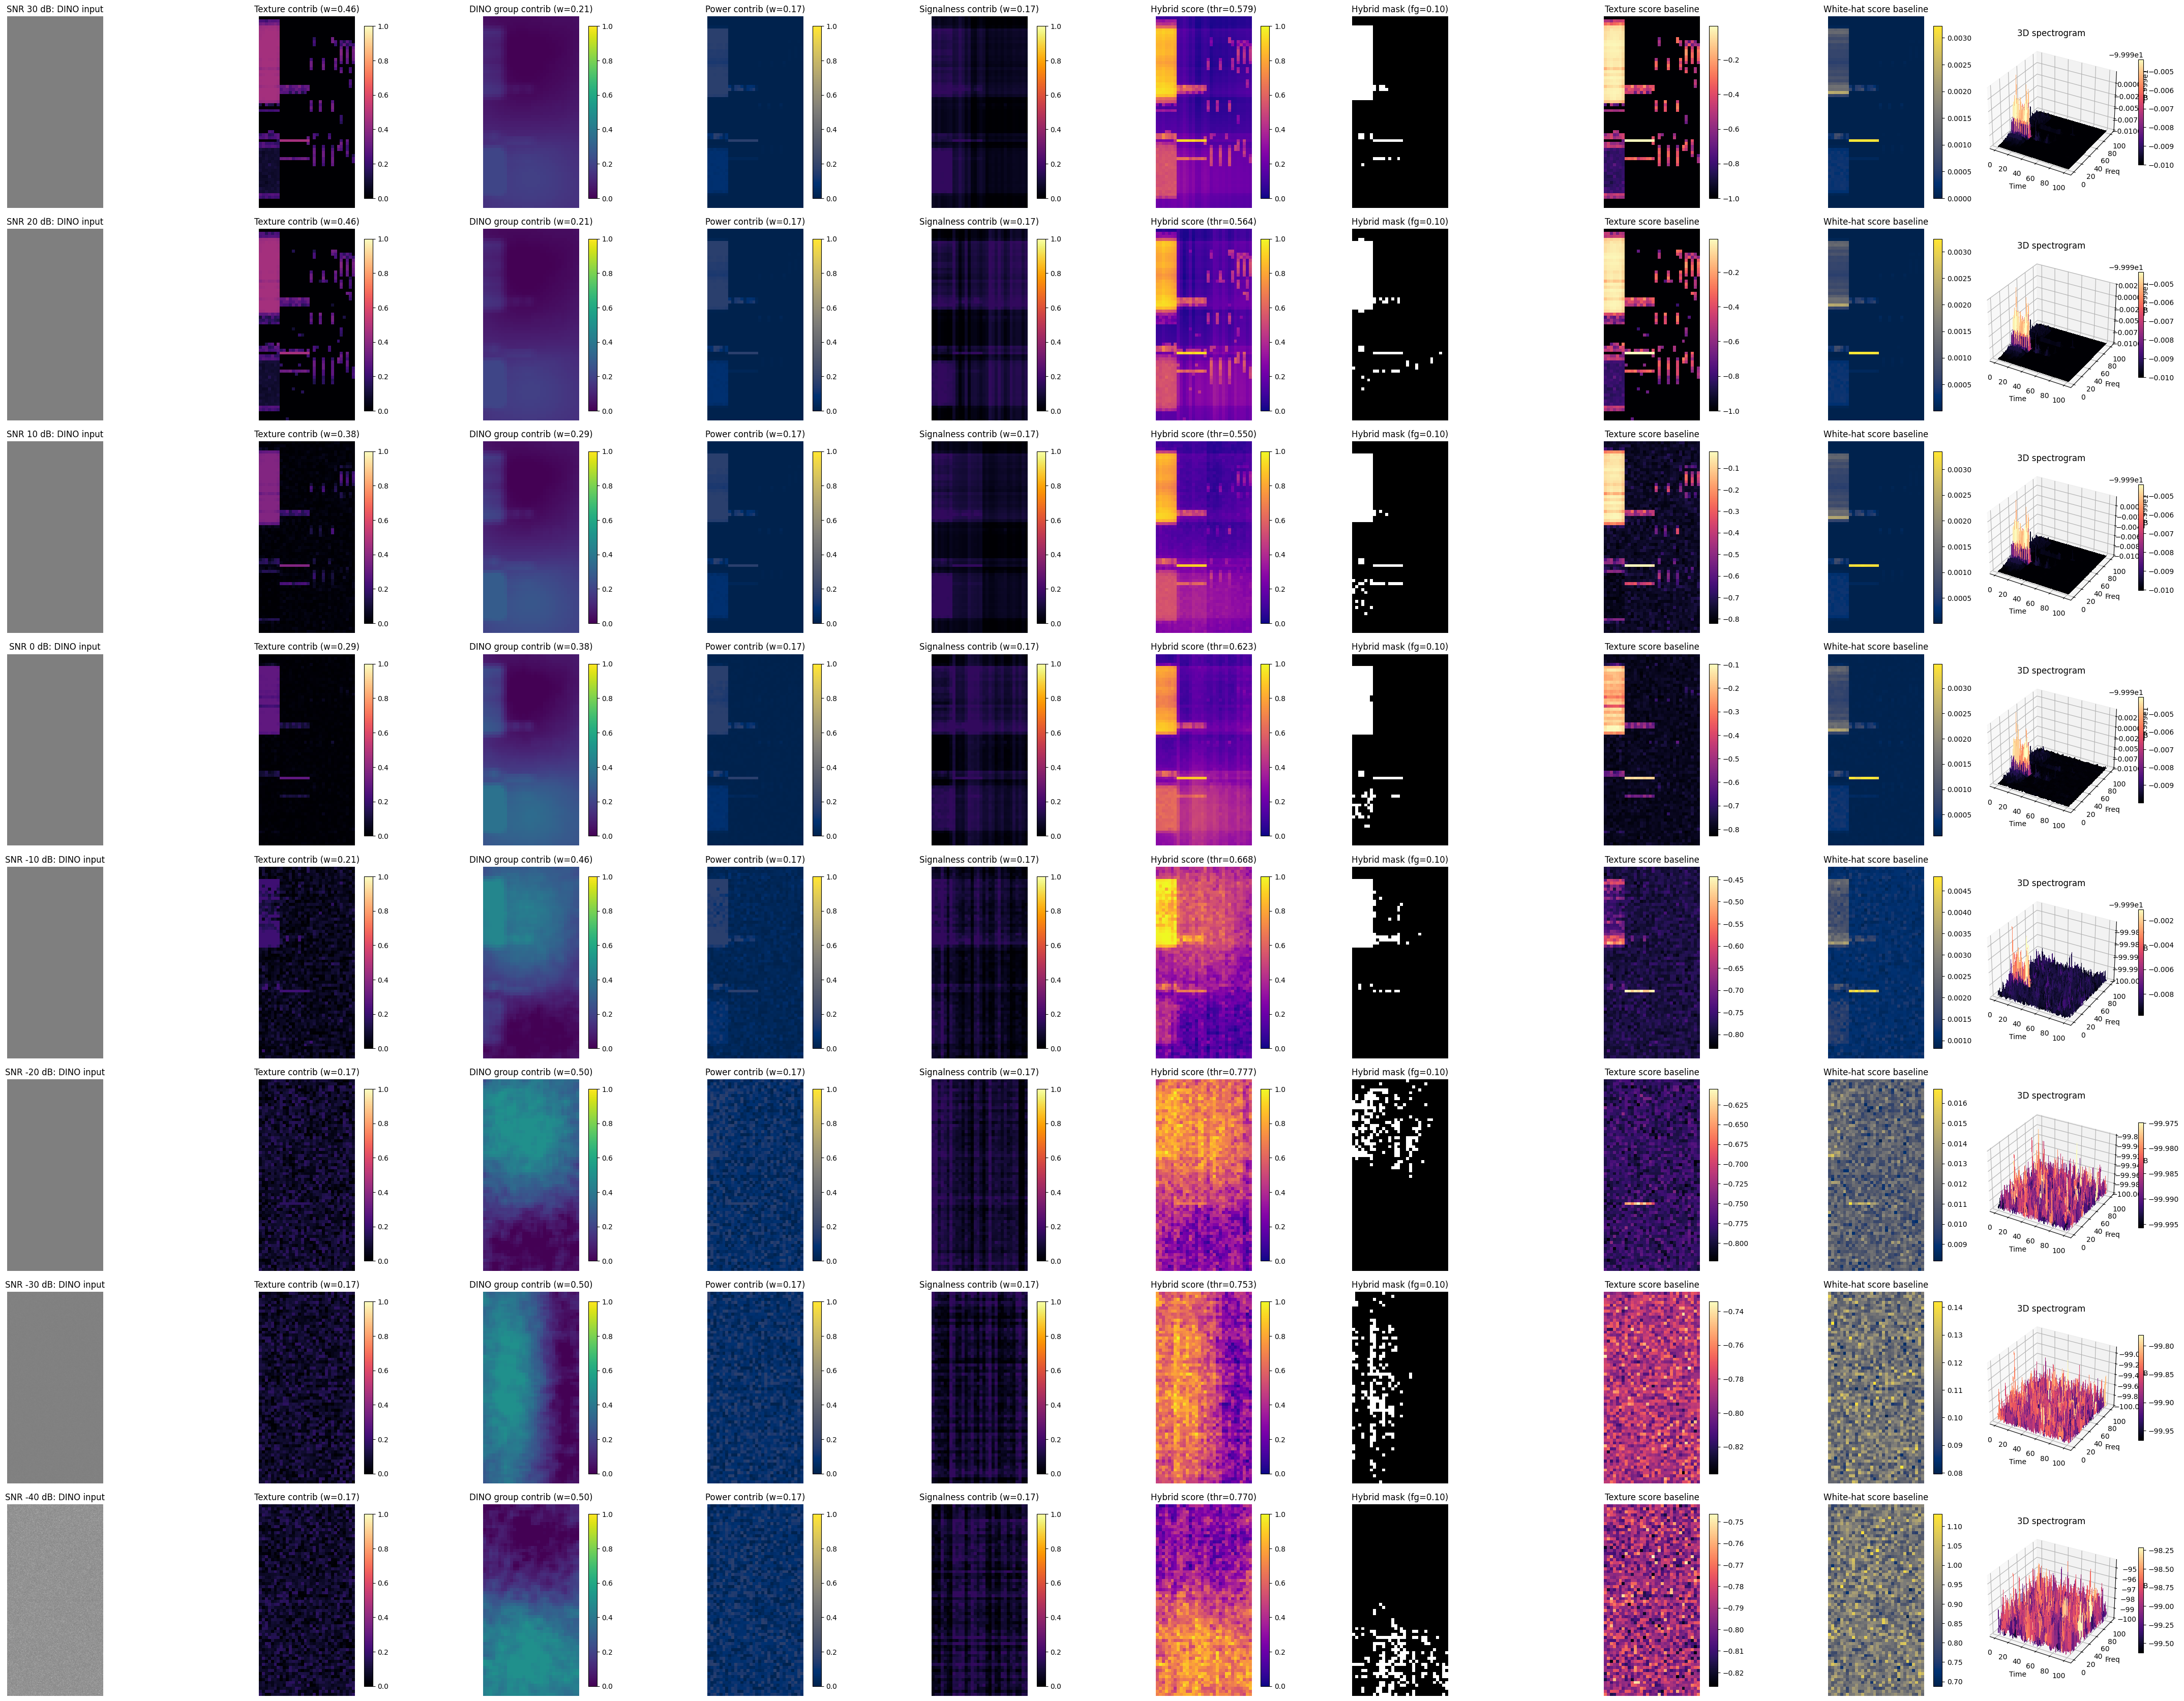

In [13]:
# Visualize hybrid components and baseline branches across SNR levels
n = len(snr_results)
fig = plt.figure(figsize=(44, 4.2 * n))

for i, r in enumerate(snr_results):
    base = i * 10

    ax_img = fig.add_subplot(n, 10, base + 1)
    ax_img.imshow(r['display_img'])
    ax_img.set_title(f"SNR {r['snr_db']} dB: DINO input")
    ax_img.axis('off')

    ax_tc = fig.add_subplot(n, 10, base + 2)
    im_tc = ax_tc.imshow(r['texture_contrib_map'], cmap='magma', vmin=0.0, vmax=1.0)
    ax_tc.set_title(f"Texture contrib (w={r['hybrid_w_texture']:.2f})")
    ax_tc.axis('off')
    fig.colorbar(im_tc, ax=ax_tc, fraction=0.046)

    ax_dc = fig.add_subplot(n, 10, base + 3)
    im_dc = ax_dc.imshow(r['dino_contrib_map'], cmap='viridis', vmin=0.0, vmax=1.0)
    ax_dc.set_title(f"DINO group contrib (w={r['hybrid_w_dino']:.2f})")
    ax_dc.axis('off')
    fig.colorbar(im_dc, ax=ax_dc, fraction=0.046)

    ax_pc = fig.add_subplot(n, 10, base + 4)
    im_pc = ax_pc.imshow(r['power_contrib_map'], cmap='cividis', vmin=0.0, vmax=1.0)
    ax_pc.set_title(f"Power contrib (w={r['hybrid_w_power']:.2f})")
    ax_pc.axis('off')
    fig.colorbar(im_pc, ax=ax_pc, fraction=0.046)

    ax_sc = fig.add_subplot(n, 10, base + 5)
    im_sc = ax_sc.imshow(r['signalness_contrib_map'], cmap='inferno', vmin=0.0, vmax=1.0)
    ax_sc.set_title(f"Signalness contrib (w={r['hybrid_w_signalness']:.2f})")
    ax_sc.axis('off')
    fig.colorbar(im_sc, ax=ax_sc, fraction=0.046)

    ax_hs = fig.add_subplot(n, 10, base + 6)
    im_hs = ax_hs.imshow(r['hybrid_score_map'], cmap='plasma', vmin=0.0, vmax=1.0)
    ax_hs.set_title(f"Hybrid score (thr={r['hybrid_threshold']:.3f})")
    ax_hs.axis('off')
    fig.colorbar(im_hs, ax=ax_hs, fraction=0.046)

    ax_hm = fig.add_subplot(n, 10, base + 7)
    ax_hm.imshow(r['hybrid_mask'], cmap='gray', vmin=0, vmax=1)
    ax_hm.set_title(f"Hybrid mask (fg={r['hybrid_foreground_fraction']:.2f})")
    ax_hm.axis('off')

    ax_tex = fig.add_subplot(n, 10, base + 8)
    im_tex = ax_tex.imshow(r['score_map'], cmap='magma')
    ax_tex.set_title('Texture score baseline')
    ax_tex.axis('off')
    fig.colorbar(im_tex, ax=ax_tex, fraction=0.046)

    ax_wh = fig.add_subplot(n, 10, base + 9)
    im_wh = ax_wh.imshow(r['whitehat_score_map'], cmap='cividis')
    ax_wh.set_title('White-hat score baseline')
    ax_wh.axis('off')
    fig.colorbar(im_wh, ax=ax_wh, fraction=0.046)

    ax_3d = fig.add_subplot(n, 10, base + 10, projection='3d')
    sxx = np.asarray(r['spectrogram_db'], dtype=np.float32)
    max_points = 96
    step_f = max(1, sxx.shape[0] // max_points)
    step_t = max(1, sxx.shape[1] // max_points)
    z = sxx[::step_f, ::step_t]
    y, x = np.meshgrid(np.arange(z.shape[1]), np.arange(z.shape[0]))
    surf = ax_3d.plot_surface(y, x, z, cmap='magma', linewidth=0, antialiased=False)
    ax_3d.view_init(elev=30, azim=-60)
    ax_3d.set_title('3D spectrogram')
    ax_3d.set_xlabel('Time')
    ax_3d.set_ylabel('Freq')
    ax_3d.set_zlabel('dB')
    fig.colorbar(surf, ax=ax_3d, shrink=0.55, pad=0.08)

plt.tight_layout()
plt.show()

## Score-to-Mask Diagnostics for Unknown SNR

This section explains and quantifies how the texture score is converted to a mask and how score distributions drift with SNR.

We compare three thresholding strategies:
1. Quantile threshold (current, fixed fraction).
2. Fixed absolute threshold (calibrated at 30 dB).
3. Normalized threshold using robust z-score (MAD-based).

Per-SNR score distribution summary:


,snr_db,mean,std,median,mad,q90,q95
0,30,-0.844165,0.305998,-1.000000,1.000000e-08,-0.300252,-0.048250
1,20,-0.837296,0.303577,-1.000000,1.000000e-08,-0.323907,-0.051736
2,10,-0.684645,0.202971,-0.760466,1.899681e-02,-0.385717,-0.070537
3,0,-0.733095,0.164056,-0.786137,1.168312e-02,-0.615633,-0.214469
4,-10,-0.776628,0.038820,-0.783724,1.050667e-02,-0.758498,-0.729212
5,-20,-0.784103,0.016425,-0.785180,8.893232e-03,-0.766993,-0.762509
6,-30,-0.786299,0.013251,-0.786654,8.920829e-03,-0.769486,-0.764150
7,-40,-0.792083,0.012473,-0.792646,8.193861e-03,-0.776004,-0.771183


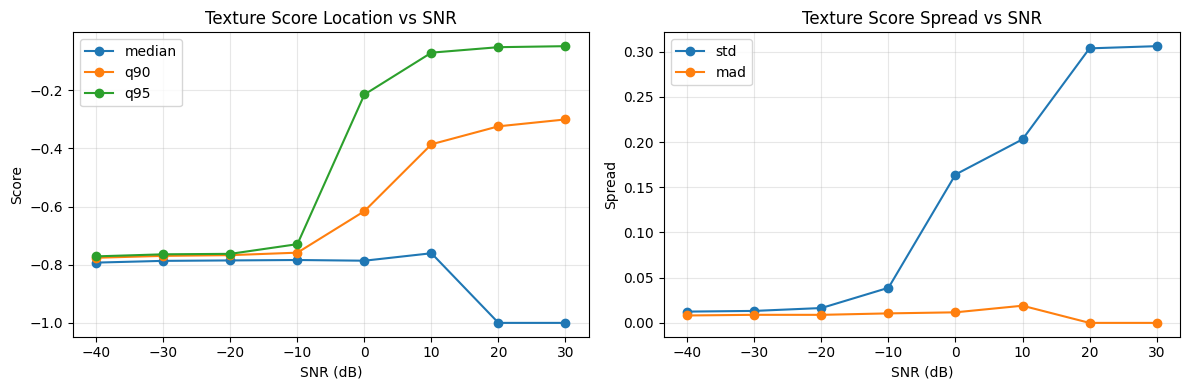

Fixed absolute threshold (from 30 dB q90): -0.300252
Robust z threshold: 3.00
Foreground fraction under different score-to-mask rules:


,snr_db,frac_quantile_q90,frac_fixed_abs,frac_robust_z
0,30,0.100098,0.100098,0.252930
1,20,0.100098,0.096680,0.275879
2,10,0.100098,0.092285,0.169922
3,0,0.100098,0.078613,0.138184
4,-10,0.100098,0.000000,0.075684
5,-20,0.100098,0.000000,0.032715
6,-30,0.100098,0.000000,0.030762
7,-40,0.100098,0.000000,0.031738


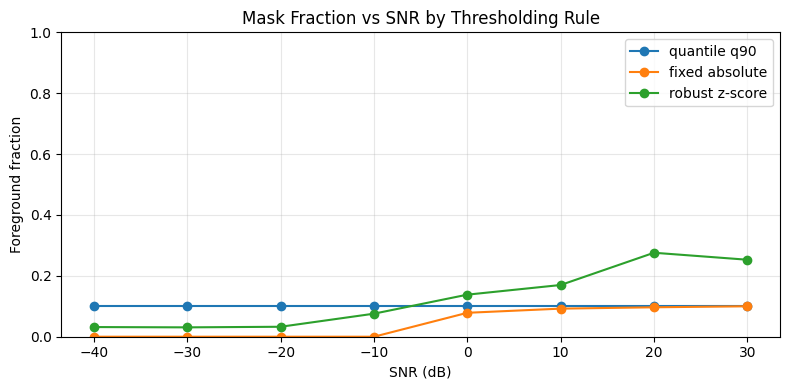

In [20]:
score_diag_rows = []
for r in snr_results:
    s = r['score_map'].reshape(-1).astype(np.float32)
    med = float(np.median(s))
    mad = float(np.median(np.abs(s - med)) + 1e-8)
    q90 = float(np.quantile(s, 0.90))
    q95 = float(np.quantile(s, 0.95))
    score_diag_rows.append({
        'snr_db': r['snr_db'],
        'mean': float(np.mean(s)),
        'std': float(np.std(s)),
        'median': med,
        'mad': mad,
        'q90': q90,
        'q95': q95,
    })

score_diag_df = pd.DataFrame(score_diag_rows).sort_values('snr_db', ascending=False)
print('Per-SNR score distribution summary:')
display(score_diag_df)

# Visualize score drift as SNR decreases.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(score_diag_df['snr_db'], score_diag_df['median'], marker='o', label='median')
ax[0].plot(score_diag_df['snr_db'], score_diag_df['q90'], marker='o', label='q90')
ax[0].plot(score_diag_df['snr_db'], score_diag_df['q95'], marker='o', label='q95')
ax[0].set_title('Texture Score Location vs SNR')
ax[0].set_xlabel('SNR (dB)')
ax[0].set_ylabel('Score')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(score_diag_df['snr_db'], score_diag_df['std'], marker='o', label='std')
ax[1].plot(score_diag_df['snr_db'], score_diag_df['mad'], marker='o', label='mad')
ax[1].set_title('Texture Score Spread vs SNR')
ax[1].set_xlabel('SNR (dB)')
ax[1].set_ylabel('Spread')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# Compare thresholding rules for mask conversion.
# 1) Quantile: always keeps ~10% by definition.
# 2) Fixed absolute threshold: calibrate at highest SNR (30 dB) q90.
# 3) Robust z-threshold: (score - median) / MAD > z_thr.
high_snr_row = max(snr_results, key=lambda x: x['snr_db'])
fixed_abs_thr = float(np.quantile(high_snr_row['score_map'], 0.90))
z_thr = 3.0

rule_rows = []
for r in snr_results:
    s = r['score_map'].reshape(-1).astype(np.float32)
    med = float(np.median(s))
    mad = float(np.median(np.abs(s - med)) + 1e-8)

    frac_quantile = float((s >= np.quantile(s, 0.90)).mean())
    frac_fixed = float((s >= fixed_abs_thr).mean())
    frac_z = float((((s - med) / mad) >= z_thr).mean())

    rule_rows.append({
        'snr_db': r['snr_db'],
        'frac_quantile_q90': frac_quantile,
        'frac_fixed_abs': frac_fixed,
        'frac_robust_z': frac_z,
    })

rule_df = pd.DataFrame(rule_rows).sort_values('snr_db', ascending=False)
print(f'Fixed absolute threshold (from 30 dB q90): {fixed_abs_thr:.6f}')
print(f'Robust z threshold: {z_thr:.2f}')
print('Foreground fraction under different score-to-mask rules:')
display(rule_df)

plt.figure(figsize=(8, 4))
plt.plot(rule_df['snr_db'], rule_df['frac_quantile_q90'], marker='o', label='quantile q90')
plt.plot(rule_df['snr_db'], rule_df['frac_fixed_abs'], marker='o', label='fixed absolute')
plt.plot(rule_df['snr_db'], rule_df['frac_robust_z'], marker='o', label='robust z-score')
plt.title('Mask Fraction vs SNR by Thresholding Rule')
plt.xlabel('SNR (dB)')
plt.ylabel('Foreground fraction')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Texture vs DINO Grouping Agreement Diagnostics

This section quantifies where the texture branch and the revised DINO grouping branch agree or diverge across the SNR sweep.

For each SNR, it reports:
- Pearson and Spearman correlation between texture and DINO grouping scores.
- IoU overlap between the actual texture mask and the actual DINO grouping mask.
- Mean absolute difference between normalized score maps.

Texture vs DINO grouping agreement summary by SNR:


,snr_db,pearson,spearman,mask_iou,mean_abs_diff_norm
0,30,0.072212,0.184813,0.000000,0.422088
1,20,0.078261,0.181292,0.001949,0.415750
2,10,0.038339,-0.012833,0.007843,0.404159
3,0,0.086521,0.031013,0.005859,0.410446
4,-10,0.262905,0.171668,0.250865,0.319832
5,-20,-0.025618,-0.022665,0.079341,0.379048
6,-30,-0.011404,-0.002694,0.069940,0.363084
7,-40,0.025722,0.027129,0.062827,0.375130


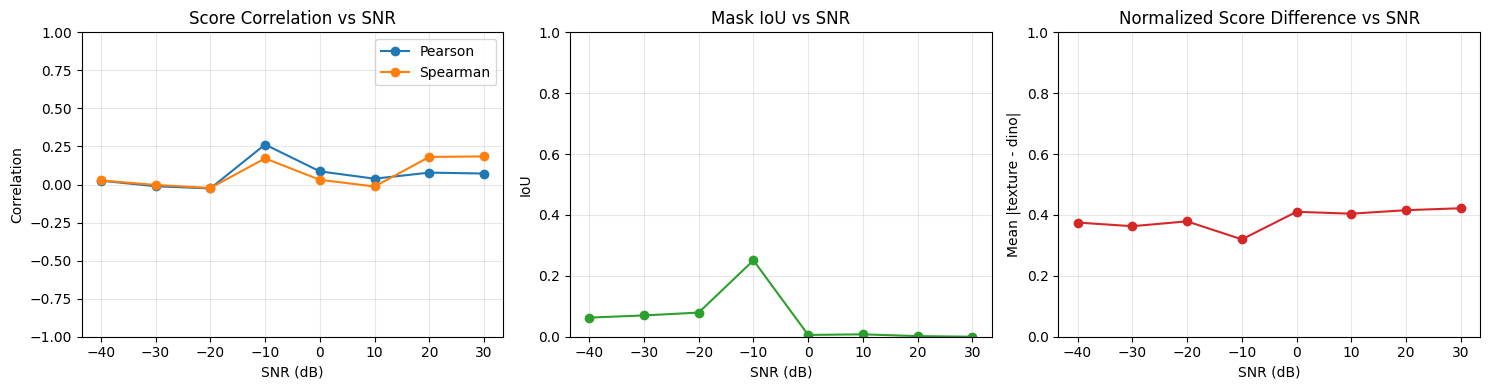

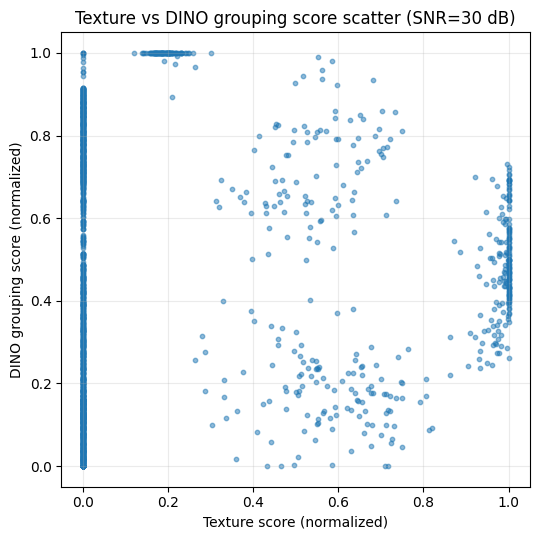

In [14]:
from scipy.stats import spearmanr, pearsonr

agreement_rows = []
for r in snr_results:
    tex = np.asarray(r['score_map'], dtype=np.float32).reshape(-1)
    dino = np.asarray(r['dino_score_map'], dtype=np.float32).reshape(-1)

    tex_n = normalize_map_01(tex, low_q=5.0, high_q=95.0)
    dino_n = normalize_map_01(dino, low_q=5.0, high_q=95.0)

    if np.std(tex_n) < 1e-8 or np.std(dino_n) < 1e-8:
        pearson_val = np.nan
    else:
        pearson_val = float(pearsonr(tex_n, dino_n)[0])

    spearman_val = float(spearmanr(tex_n, dino_n).correlation)

    tex_mask = np.asarray(r['mask'], dtype=np.uint8).reshape(-1).astype(bool)
    dino_mask = np.asarray(r['dino_mask'], dtype=np.uint8).reshape(-1).astype(bool)
    inter = float(np.logical_and(tex_mask, dino_mask).sum())
    union = float(np.logical_or(tex_mask, dino_mask).sum())
    mask_iou = inter / max(union, 1.0)

    mad_norm = float(np.mean(np.abs(tex_n - dino_n)))

    agreement_rows.append({
        'snr_db': r['snr_db'],
        'pearson': pearson_val,
        'spearman': spearman_val,
        'mask_iou': mask_iou,
        'mean_abs_diff_norm': mad_norm,
    })

agreement_df = pd.DataFrame(agreement_rows).sort_values('snr_db', ascending=False)
print('Texture vs DINO grouping agreement summary by SNR:')
display(agreement_df)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(agreement_df['snr_db'], agreement_df['pearson'], marker='o', label='Pearson')
ax[0].plot(agreement_df['snr_db'], agreement_df['spearman'], marker='o', label='Spearman')
ax[0].set_title('Score Correlation vs SNR')
ax[0].set_xlabel('SNR (dB)')
ax[0].set_ylabel('Correlation')
ax[0].set_ylim(-1.0, 1.0)
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(agreement_df['snr_db'], agreement_df['mask_iou'], marker='o', color='tab:green')
ax[1].set_title('Mask IoU vs SNR')
ax[1].set_xlabel('SNR (dB)')
ax[1].set_ylabel('IoU')
ax[1].set_ylim(0.0, 1.0)
ax[1].grid(True, alpha=0.3)

ax[2].plot(agreement_df['snr_db'], agreement_df['mean_abs_diff_norm'], marker='o', color='tab:red')
ax[2].set_title('Normalized Score Difference vs SNR')
ax[2].set_xlabel('SNR (dB)')
ax[2].set_ylabel('Mean |texture - dino|')
ax[2].set_ylim(0.0, 1.0)
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ref = max(snr_results, key=lambda x: x['snr_db'])
tex_ref = normalize_map_01(np.asarray(ref['score_map'], dtype=np.float32))
dino_ref = normalize_map_01(np.asarray(ref['dino_score_map'], dtype=np.float32))

plt.figure(figsize=(5.5, 5.5))
plt.scatter(tex_ref.reshape(-1), dino_ref.reshape(-1), s=10, alpha=0.5)
plt.title(f"Texture vs DINO grouping score scatter (SNR={ref['snr_db']} dB)")
plt.xlabel('Texture score (normalized)')
plt.ylabel('DINO grouping score (normalized)')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## DINO Grouping Ablation

This ablation compares four DINO grouping variants on the same SNR sweep:
1. Fixed gray + seed prior + spatial graph (current baseline).
2. Fixed gray + no seed prior.
3. Fixed gray + weaker spatial graph.
4. RGB input + seed prior + spatial graph.

For each variant, we report:
- Pearson and Spearman correlation to the baseline grouping score map.
- IoU overlap of the final masks vs baseline.
- Mean absolute difference between normalized score maps.

This shows whether input rendering, seed usage, and spatial graph strength materially change the grouped regions.

DINO grouping ablation summary (reference = gray_seeded_spatial035):


,snr_db,variant,pearson_vs_baseline,spearman_vs_baseline,mask_iou_vs_baseline,mean_abs_diff_norm_vs_baseline
1,30,gray_no_seed_spatial035,0.364865,0.274211,0.218023,0.206492
5,20,gray_no_seed_spatial035,0.364850,0.274238,0.218023,0.206538
9,10,gray_no_seed_spatial035,0.365248,0.275884,0.218023,0.206467
13,0,gray_no_seed_spatial035,0.369388,0.291655,0.218023,0.205214
17,-10,gray_no_seed_spatial035,0.368016,0.340057,0.204748,0.197282
21,-20,gray_no_seed_spatial035,-0.086403,0.326106,0.041597,0.352756
25,-30,gray_no_seed_spatial035,0.366709,0.655320,0.062622,0.282967
29,-40,gray_no_seed_spatial035,0.790345,0.807031,0.639706,0.092745
2,30,gray_seeded_spatial015,0.837097,0.910385,0.625000,0.046681
6,20,gray_seeded_spatial015,0.837059,0.910248,0.625000,0.046644


Average agreement across SNR sweep:


,variant,pearson_vs_baseline,spearman_vs_baseline,mask_iou_vs_baseline,mean_abs_diff_norm_vs_baseline
0,gray_no_seed_spatial035,0.362877,0.405563,0.227596,0.218808
1,gray_seeded_spatial015,0.803789,0.870135,0.664261,0.071980
2,gray_seeded_spatial035,1.000000,1.000000,1.000000,0.000000
3,rgb_seeded_spatial035,0.470418,0.279633,0.254081,0.190642


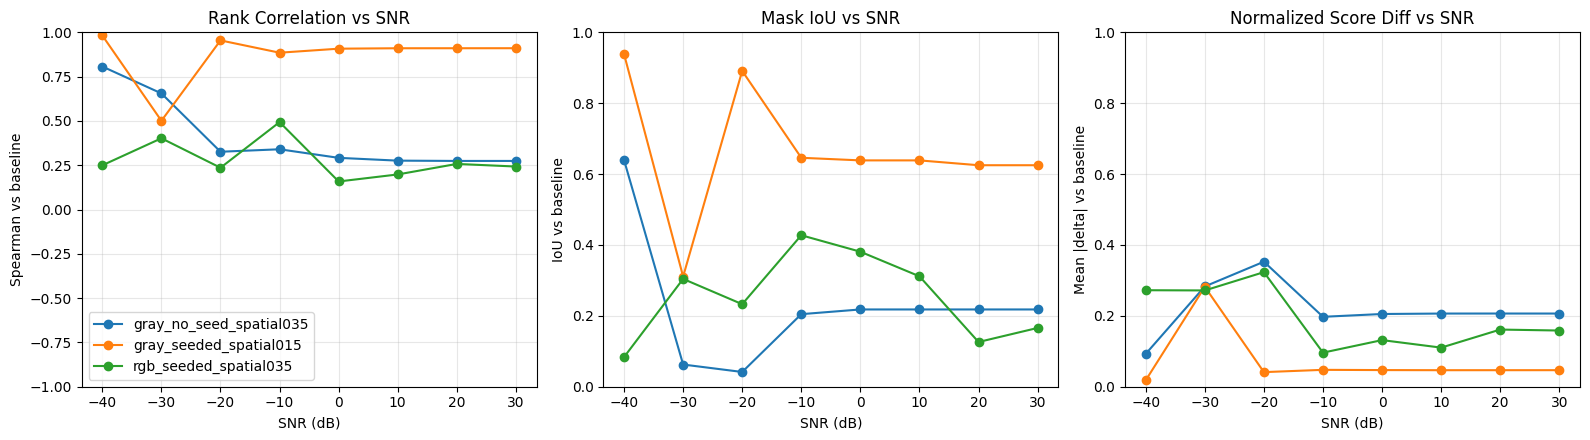

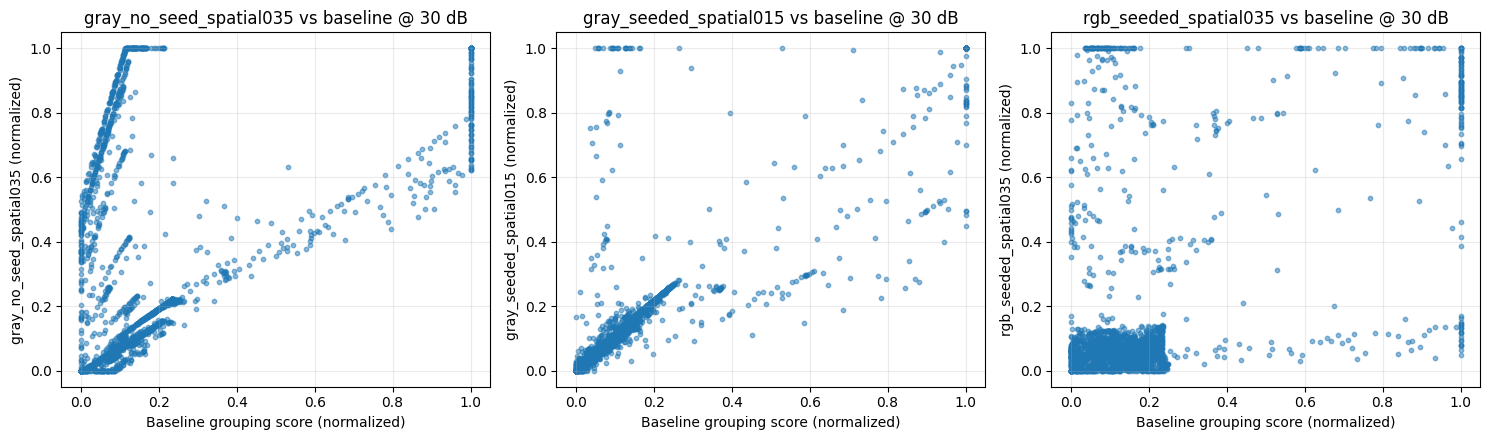

In [33]:
from scipy.stats import pearsonr, spearmanr


def dino_group_variant_from_sxx(
    sxx_db_local,
    variant_name,
    db_min,
    db_max,
    feature_knn=8,
    random_state=42,
):
    if variant_name == 'gray_seeded_spatial035':
        input_img = _db_to_fixed_grayscale_rgb(sxx_db_local, db_min=db_min, db_max=db_max)
        use_seed = True
        spatial_weight = 0.35
        score_q = 0.60
    elif variant_name == 'gray_no_seed_spatial035':
        input_img = _db_to_fixed_grayscale_rgb(sxx_db_local, db_min=db_min, db_max=db_max)
        use_seed = False
        spatial_weight = 0.35
        score_q = 0.60
    elif variant_name == 'gray_seeded_spatial015':
        input_img = _db_to_fixed_grayscale_rgb(sxx_db_local, db_min=db_min, db_max=db_max)
        use_seed = True
        spatial_weight = 0.15
        score_q = 0.60
    elif variant_name == 'rgb_seeded_spatial035':
        input_img, _, _ = spectrogram_to_rgb(sxx_db_local)
        use_seed = True
        spatial_weight = 0.35
        score_q = 0.60
    else:
        raise ValueError(f'Unknown variant: {variant_name}')

    feat_local, gh, gw, input_img = _extract_dino_features_from_rgb(input_img)
    seed_patch = dino_seed_patch_map(sxx_db_local, gh, gw) if use_seed else np.zeros((gh, gw), dtype=np.float32)
    run = dino_region_grouping_mask(
        feat_local,
        patch_h=gh,
        patch_w=gw,
        seed_patch=seed_patch,
        feature_knn=feature_knn,
        spatial_weight=spatial_weight,
        score_q=score_q,
        smooth_iters=2,
        min_component_size=6,
        random_state=random_state,
    )
    run.update({'input_img': input_img, 'seed_patch': seed_patch})
    return run


abl_configs = [
    'gray_seeded_spatial035',
    'gray_no_seed_spatial035',
    'gray_seeded_spatial015',
    'rgb_seeded_spatial035',
]

abl_rows = []
abl_maps = {name: [] for name in abl_configs}

for r in snr_results:
    variant_cache = {}
    for name in abl_configs:
        run = dino_group_variant_from_sxx(
            r['spectrogram_db'],
            variant_name=name,
            db_min=r['dino_input_vmin'],
            db_max=r['dino_input_vmax'],
            feature_knn=DINO_GROUP_K,
            random_state=42,
        )
        variant_cache[name] = run
        abl_maps[name].append({'snr_db': r['snr_db'], 'score': run['score'], 'mask': run['mask']})

    baseline = variant_cache['gray_seeded_spatial035']
    base_n = normalize_map_01(baseline['score'], low_q=5.0, high_q=95.0).reshape(-1)
    base_m = baseline['mask'].reshape(-1).astype(bool)

    for name in abl_configs:
        cur_s = variant_cache[name]['score']
        cur_m = variant_cache[name]['mask']
        cur_n = normalize_map_01(cur_s, low_q=5.0, high_q=95.0).reshape(-1)
        cur_m_flat = cur_m.reshape(-1).astype(bool)

        if np.std(base_n) < 1e-8 or np.std(cur_n) < 1e-8:
            p = np.nan
        else:
            p = float(pearsonr(base_n, cur_n)[0])
        s = float(spearmanr(base_n, cur_n).correlation)

        inter = float(np.logical_and(base_m, cur_m_flat).sum())
        union = float(np.logical_or(base_m, cur_m_flat).sum())
        iou = inter / max(union, 1.0)

        abl_rows.append({
            'snr_db': r['snr_db'],
            'variant': name,
            'pearson_vs_baseline': p,
            'spearman_vs_baseline': s,
            'mask_iou_vs_baseline': iou,
            'mean_abs_diff_norm_vs_baseline': float(np.mean(np.abs(base_n - cur_n))),
        })

ablation_df = pd.DataFrame(abl_rows).sort_values(['variant', 'snr_db'], ascending=[True, False])
print('DINO grouping ablation summary (reference = gray_seeded_spatial035):')
display(ablation_df)

agg_df = (
    ablation_df
    .groupby('variant', as_index=False)
    .agg({
        'pearson_vs_baseline': 'mean',
        'spearman_vs_baseline': 'mean',
        'mask_iou_vs_baseline': 'mean',
        'mean_abs_diff_norm_vs_baseline': 'mean',
    })
    .sort_values('variant')
)
print('Average agreement across SNR sweep:')
display(agg_df)

plot_variants = [v for v in ablation_df['variant'].unique() if v != 'gray_seeded_spatial035']
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for v in plot_variants:
    d = ablation_df[ablation_df['variant'] == v].sort_values('snr_db', ascending=False)
    ax[0].plot(d['snr_db'], d['spearman_vs_baseline'], marker='o', label=v)
    ax[1].plot(d['snr_db'], d['mask_iou_vs_baseline'], marker='o', label=v)
    ax[2].plot(d['snr_db'], d['mean_abs_diff_norm_vs_baseline'], marker='o', label=v)

ax[0].set_title('Rank Correlation vs SNR')
ax[0].set_xlabel('SNR (dB)')
ax[0].set_ylabel('Spearman vs baseline')
ax[0].set_ylim(-1.0, 1.0)
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].set_title('Mask IoU vs SNR')
ax[1].set_xlabel('SNR (dB)')
ax[1].set_ylabel('IoU vs baseline')
ax[1].set_ylim(0.0, 1.0)
ax[1].grid(True, alpha=0.3)

ax[2].set_title('Normalized Score Diff vs SNR')
ax[2].set_xlabel('SNR (dB)')
ax[2].set_ylabel('Mean |delta| vs baseline')
ax[2].set_ylim(0.0, 1.0)
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ref_snr = max(r['snr_db'] for r in snr_results)
idx_ref = next(i for i, r in enumerate(snr_results) if r['snr_db'] == ref_snr)
base_ref = normalize_map_01(abl_maps['gray_seeded_spatial035'][idx_ref]['score']).reshape(-1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for j, v in enumerate(['gray_no_seed_spatial035', 'gray_seeded_spatial015', 'rgb_seeded_spatial035']):
    cur_ref = normalize_map_01(abl_maps[v][idx_ref]['score']).reshape(-1)
    ax[j].scatter(base_ref, cur_ref, s=10, alpha=0.5)
    ax[j].set_title(f'{v} vs baseline @ {ref_snr} dB')
    ax[j].set_xlabel('Baseline grouping score (normalized)')
    ax[j].set_ylabel(f'{v} (normalized)')
    ax[j].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()